# Exploratory Data Analysis of the Link between Aspiration, Experience, and Skill with Task Allocation


This notebook provides exploratory data analysis on the dataframe created in the previous notebook by combining survey tasks and attributions data. The data file we are analyzing connects survey task responses with the actual tasks participants performed (gathered from their attributions page) and is located at:
`../results/survey_tasks_and_attributions/2023_survey_tasks_and_attributions_combined.tsv`

The **Certainty** column reflects a person's confidence in their skill for a given task.

**Survey Question:**
*Degree of certainty in your ability to perform the task described in your capacity as an iGEM team member.*

**Answers:**
'Completely unsure', 'Somewhat unsure', 'Neutral', 'Somewhat sure', 'Completely sure'


The **Experience** column records the number of years of experience the person has in performing a given task.

**Survey Question:**
*Number of years of work experience or formal/informal training you received on the task before the start of the 2023 iGEM competition.*

**Answers:**
'Less than one year', 'Between one and two years',
'Between two and three years', 'Between three and four years',
'Between four and five years', 'Between five and six years', 'More than six years'


The **Preference** column indicates the participant’s interest in doing a particular task.

**Survey Question:**
*If I had the option, I would choose to work on this task in my capacity as an iGEM team member.*

**Answers:**
'Strongly disagree', 'Somewhat disagree', 'Neutral', 'Somewhat agree', 'Strongly agree'

The **TaskPerformed** column contains values of `1`, `0`, or `null`, depending on whether a person actually performed a task (extracted from their team's attributions form). A `null` value means they could not be matched to any attributions data (e.g. their team did not submit an attributions form).

The goal of this analysis is to explore potential links between **aspiration, confidence, experience**, and **actual task performance**. Did people perform tasks they liked, felt confident in, or had experience with? Are these good predictors of task performance?


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr
import numpy as np
import statsmodels.formula.api as smf
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from sklearn.preprocessing import StandardScaler
import re
from matplotlib.colors import TwoSlopeNorm

DATASET_ORDER = [
    "2023 Survey + Attributions",
    "2022 LLM Survey + Attributions",
]

In [56]:
# Plot Configuration

# Color palette
sns.set_palette("deep")

# Styles for seaborn
sns.set_context("notebook", rc={
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.titlepad": 20,     
    "axes.labelpad": 20 
})

# Styles for matplotlib
plt.rcParams.update({
    'axes.titleweight': 'bold',
    'figure.figsize': (12, 8),
    'axes.titlepad': 20,   
    'axes.labelpad': 20,  
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.titlepad": 20,     
    "axes.labelpad": 20 
})

## 1. Basic Data Exploration

- basic exploration (dataframe shape, data types, row counts, null values)


In [57]:
survey_and_attributions_2023_df = pd.read_table(
    "../results/survey_tasks_and_attributions/2023_survey_tasks_and_attributions_combined.tsv"
)
survey_and_attributions_2022_llm_df = pd.read_table(
    "../results/survey_tasks_and_attributions/2022_survey_tasks_and_attributions_combined_llm.tsv"
)

DATASETS = {
    "2023 Survey + Attributions": survey_and_attributions_2023_df,
    "2022 LLM Survey + Attributions": survey_and_attributions_2022_llm_df,
}

# Keep legacy variable name for compatibility with downstream cells.
survey_and_attributions_df = DATASETS["2023 Survey + Attributions"]

In [58]:
survey_and_attributions_df.head()

,Team,TeamMember,Role,Task,Certainty,Experience,Preference,TaskPerformed
0,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Analysis,Somewhat unsure,Between one and two years,Neutral,0.0
1,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Background Research,Somewhat sure,Between one and two years,Neutral,1.0
2,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Conceptualization,Neutral,Less than one year,Neutral,1.0
3,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Data Curation,Somewhat unsure,Less than one year,Somewhat disagree,0.0
4,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Entrepreneurship,Neutral,Less than one year,Somewhat disagree,0.0


In [59]:
survey_and_attributions_df.shape

(7095, 8)

In [60]:
survey_and_attributions_df.dtypes

Team              object
TeamMember        object
Role              object
Task              object
Certainty         object
Experience        object
Preference        object
TaskPerformed    float64
dtype: object

In [61]:
# convert TaskPerformed to nullable int (it was int before but after pd.read_table it gets turned into float)

for title in DATASET_ORDER:
    DATASETS[title]['TaskPerformed'] = DATASETS[title]['TaskPerformed'].astype('Int64')

# Keep legacy variable name for compatibility with downstream cells.
survey_and_attributions_df = DATASETS["2023 Survey + Attributions"]

In [62]:
survey_and_attributions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7095 entries, 0 to 7094
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Team           7095 non-null   object
 1   TeamMember     7095 non-null   object
 2   Role           6735 non-null   object
 3   Task           7095 non-null   object
 4   Certainty      7050 non-null   object
 5   Experience     7000 non-null   object
 6   Preference     6957 non-null   object
 7   TaskPerformed  6286 non-null   Int64 
dtypes: Int64(1), object(7)
memory usage: 450.5+ KB


In [63]:
survey_and_attributions_df.head()

,Team,TeamMember,Role,Task,Certainty,Experience,Preference,TaskPerformed
0,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Analysis,Somewhat unsure,Between one and two years,Neutral,0
1,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Background Research,Somewhat sure,Between one and two years,Neutral,1
2,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Conceptualization,Neutral,Less than one year,Neutral,1
3,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Data Curation,Somewhat unsure,Less than one year,Somewhat disagree,0
4,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Entrepreneurship,Neutral,Less than one year,Somewhat disagree,0


In [64]:
survey_and_attributions_df["Certainty"].unique()

array(['Somewhat unsure', 'Somewhat sure', 'Neutral', 'Completely unsure',
       'Completely sure', nan], dtype=object)

In [65]:
survey_and_attributions_df["Experience"].unique()

array(['Between one and two years', 'Less than one year',
       'Between two and three years', 'Between three and four years', nan,
       'Between five and six years', 'More than six years',
       'Between four and five years'], dtype=object)

In [66]:
survey_and_attributions_df["Preference"].unique()

array(['Neutral', 'Somewhat disagree', 'Somewhat agree', 'Strongly agree',
       'Strongly disagree', nan], dtype=object)

In [67]:
survey_and_attributions_df["Role"].unique()

array(['Student Leader', 'Student Member', 'Secondary PI', nan, 'Advisor',
       'Primary PI', 'Instructor'], dtype=object)

In [68]:
# number of team members per role (only unique names counted)
unique_counts = (
    survey_and_attributions_df
    .groupby("Role")["TeamMember"]
    .nunique()
    .rename("unique_member_count")
    .reset_index()
)
print(unique_counts)

             Role  unique_member_count
0         Advisor                    4
1      Instructor                    8
2      Primary PI                    4
3    Secondary PI                    4
4  Student Leader                   78
5  Student Member                  351


In [69]:
survey_and_attributions_df["TeamMember"].nunique()

473

In [70]:
survey_and_attributions_df["Team"].nunique()

100

In [71]:
# Number of unique teams with no tasks performed values for some survey participants
survey_and_attributions_df[survey_and_attributions_df["TaskPerformed"].isna()]["Team"].nunique()

100

In [72]:
# Number of unique teams members with no tasks performed
survey_and_attributions_df[survey_and_attributions_df["TaskPerformed"].isna()]["TeamMember"].nunique()


473

The survey mostly targeted students, with 351 out of total 473 respondents being student members and 78 student leaders. Out of 473 respondents, 24 of them do not have a value for the TaskPerformed column. Those respondents represent 6 unique teams that did not submit their attribution forms, were disqualified, or some of their members were not mentioned in the attribution form. The survey has responses from 100 different teams, out of which 94 have attribution forms with all members mentioned. All the null TaskPerformed values will be dropped in the analysis.

In [73]:
# Total number of rows
total_rows = len(survey_and_attributions_df)

# Number of rows where TaskPerformed == 0
task_not_performed = (survey_and_attributions_df['TaskPerformed'] == 0).sum()

# Number of rows where TaskPerformed == 1
task_performed = (survey_and_attributions_df['TaskPerformed'] == 1).sum()

# Number of rows where TaskPerformed is null 
task_performance_null = survey_and_attributions_df['TaskPerformed'].isna().sum()

print(f"Total rows: {total_rows}")
print(f"TaskPerformed == 0: {task_not_performed}")
print(f"TaskPerformed == 1: {task_performed}")
print(f"TaskPerformed == NA: {task_performance_null}")

Total rows: 7095
TaskPerformed == 0: 3472
TaskPerformed == 1: 2814
TaskPerformed == NA: 809


## 2. Distribution of Task Survey Categories

- barplots of distribution of answers for task survey categories (experience, certainty…), with values from low to high (less than 1 year, between 1 and 2 years etc)
- probability distribution of a task being preformed based on different aswers for certainty, experience and preference

### 2.1 All Roles

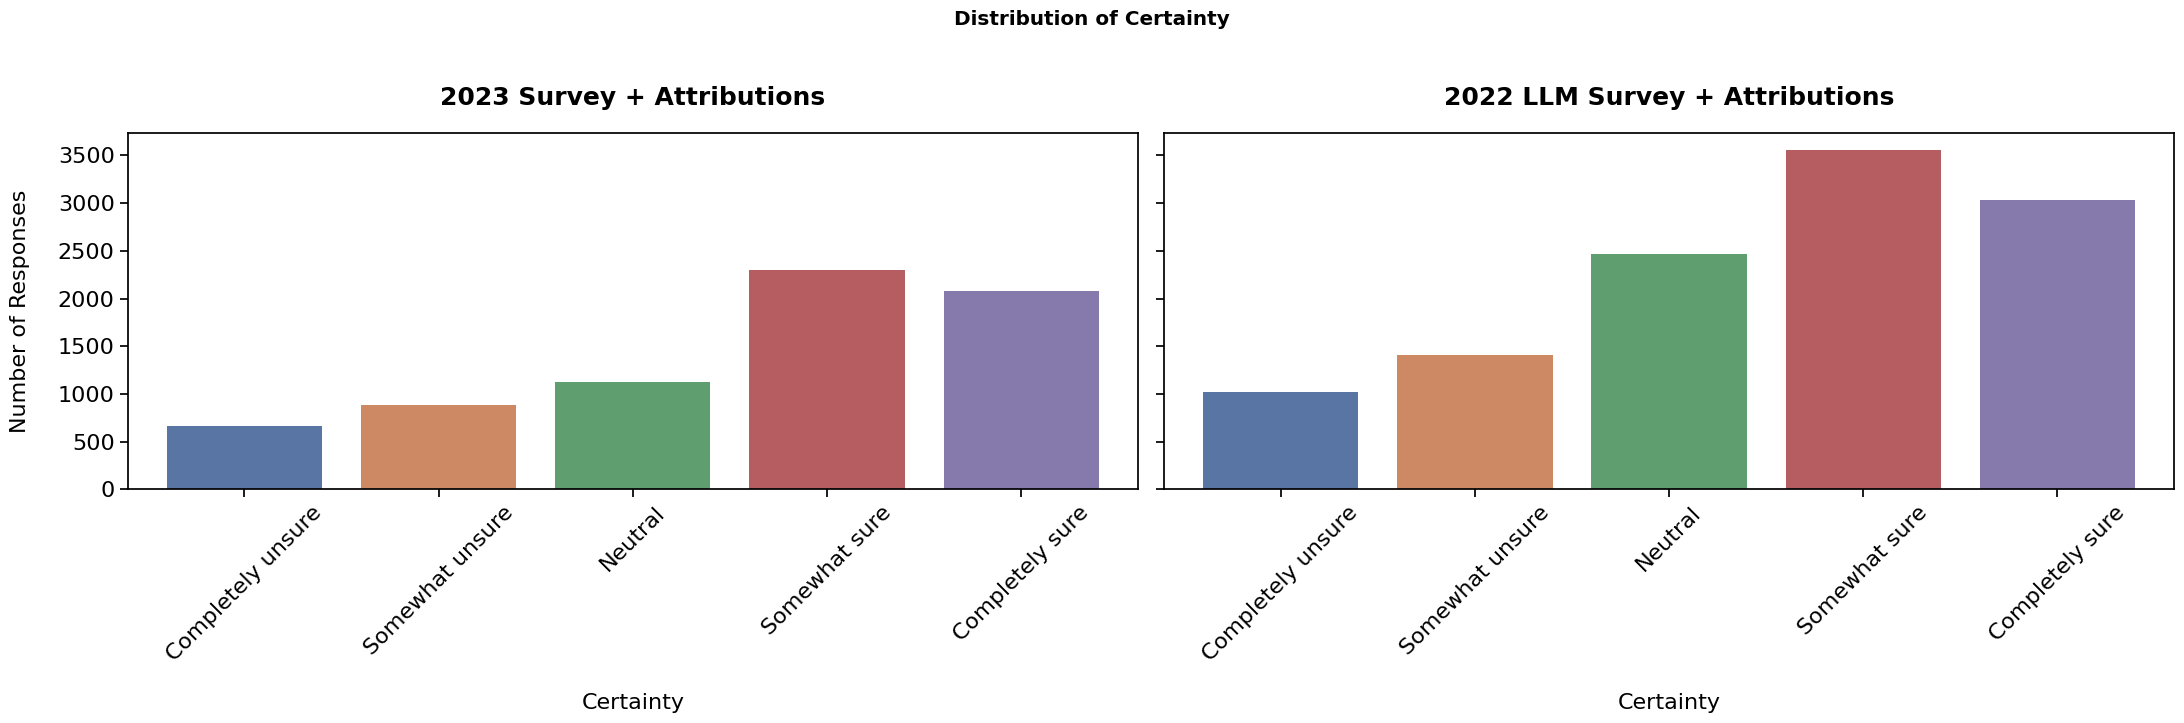

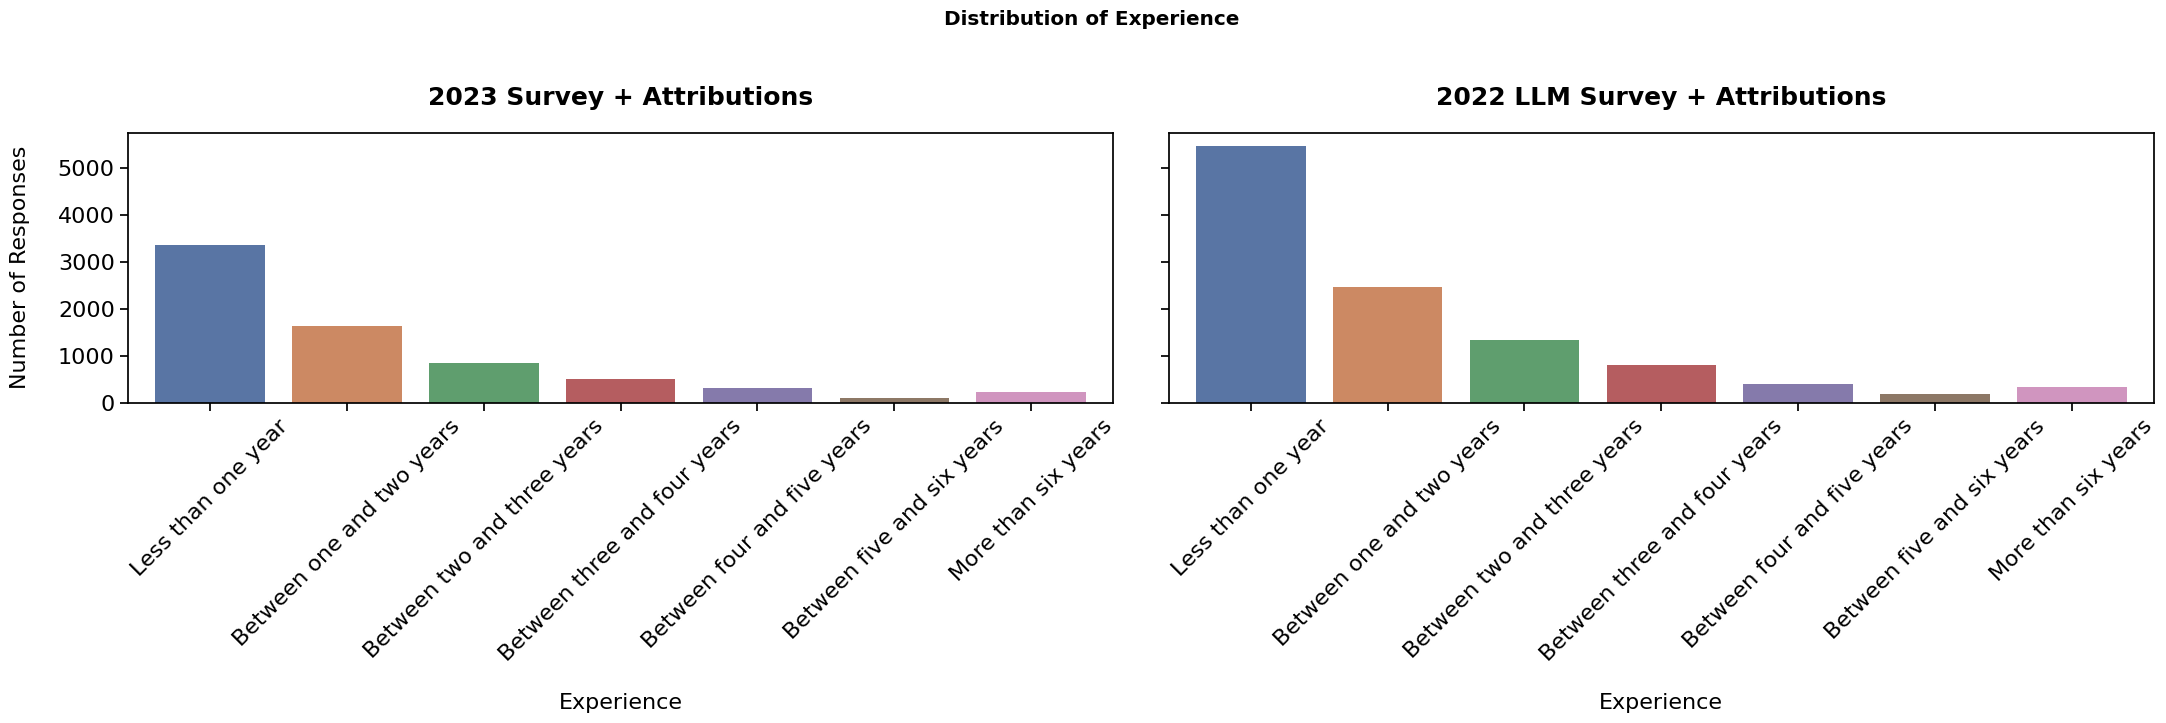

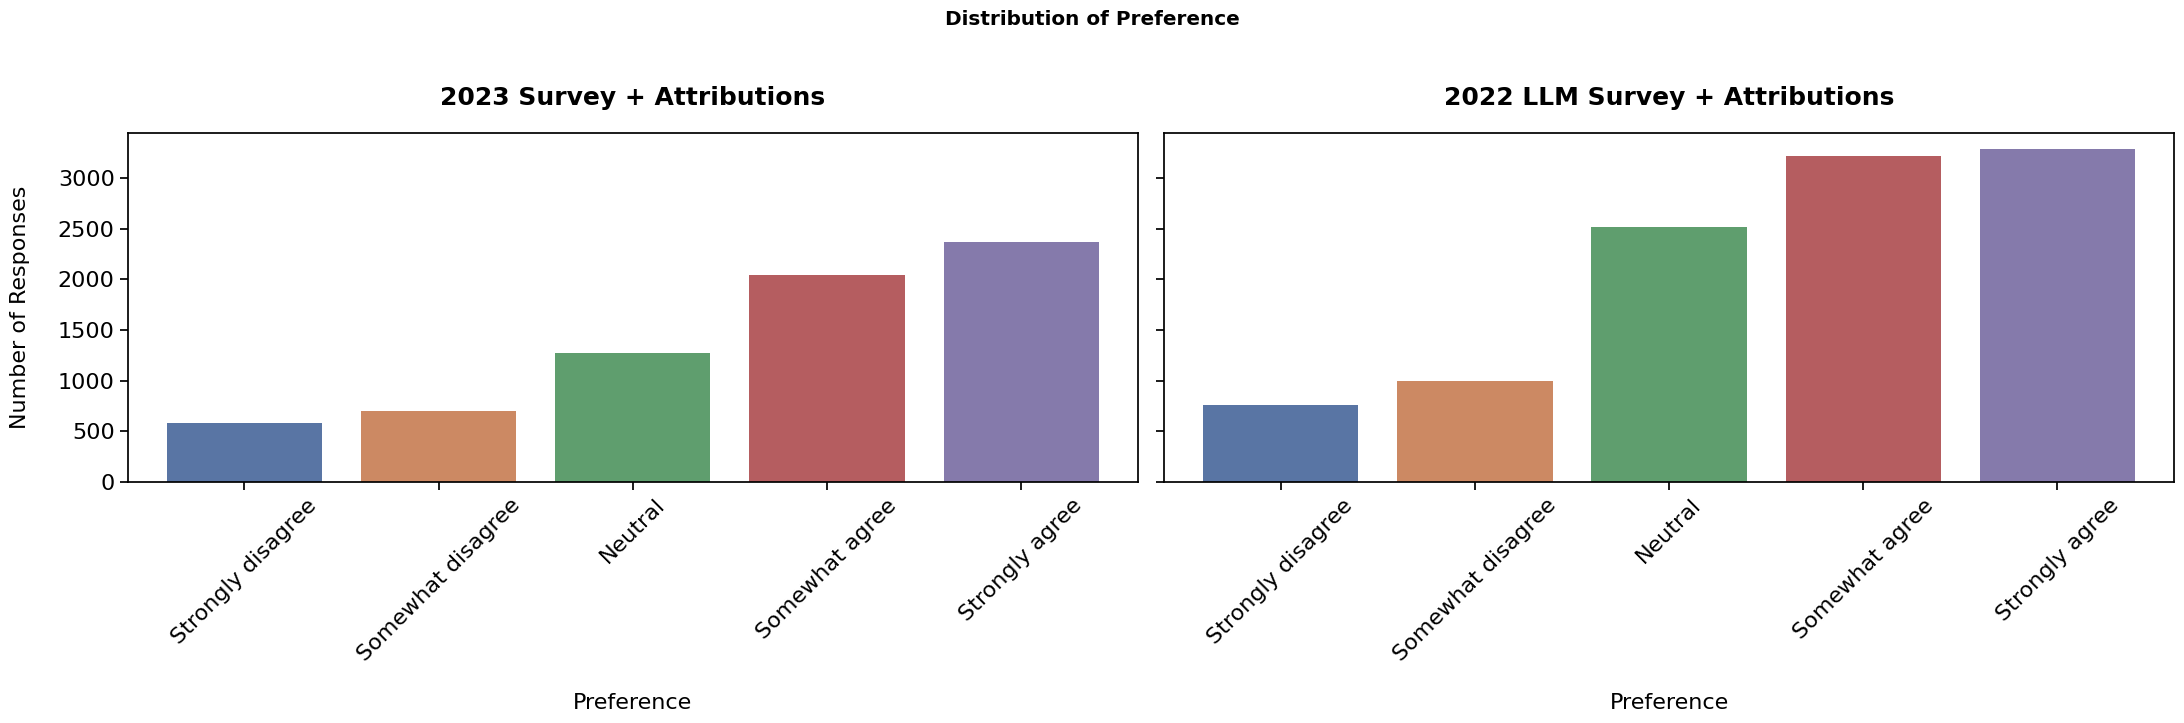

In [74]:
# Distribution of Certainty, Experience, and Preference answers: y axis is the total number of responses

# Define order of categories
category_orders = {
    'Certainty': [
        'Completely unsure',
        'Somewhat unsure',
        'Neutral',
        'Somewhat sure',
        'Completely sure'
    ],
    'Experience': [
        'Less than one year',
        'Between one and two years',
        'Between two and three years',
        'Between three and four years',
        'Between four and five years',
        'Between five and six years',
        'More than six years'
    ],
    'Preference': [
        'Strongly disagree',
        'Somewhat disagree',
        'Neutral',
        'Somewhat agree',
        'Strongly agree'
    ]
}

# Make one base palette as long as the longest list
max_levels = max(len(v) for v in category_orders.values())
base_palette = sns.color_palette(n_colors=max_levels)

for col, order in category_orders.items():
    this_palette = {level: base_palette[i] for i, level in enumerate(order)}

    fig, axes = plt.subplots(1, 2, figsize=(22, 7), sharey=True)
    for ax, title in zip(axes, DATASET_ORDER):
        sns.countplot(
            data=DATASETS[title],
            x=col,
            order=order,
            hue=col,
            palette=this_palette,
            legend=False,
            ax=ax,
        )

        xmin, xmax = ax.get_xlim()
        ax.set_xlim(xmin - 0.1, xmax + 0.1)
        ax.set_title(title)
        ax.set_xlabel(col)
        ax.set_ylabel('Number of Responses')
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle(f'Distribution of {col}', y=1.03, weight='bold')
    plt.tight_layout()
    plt.show()

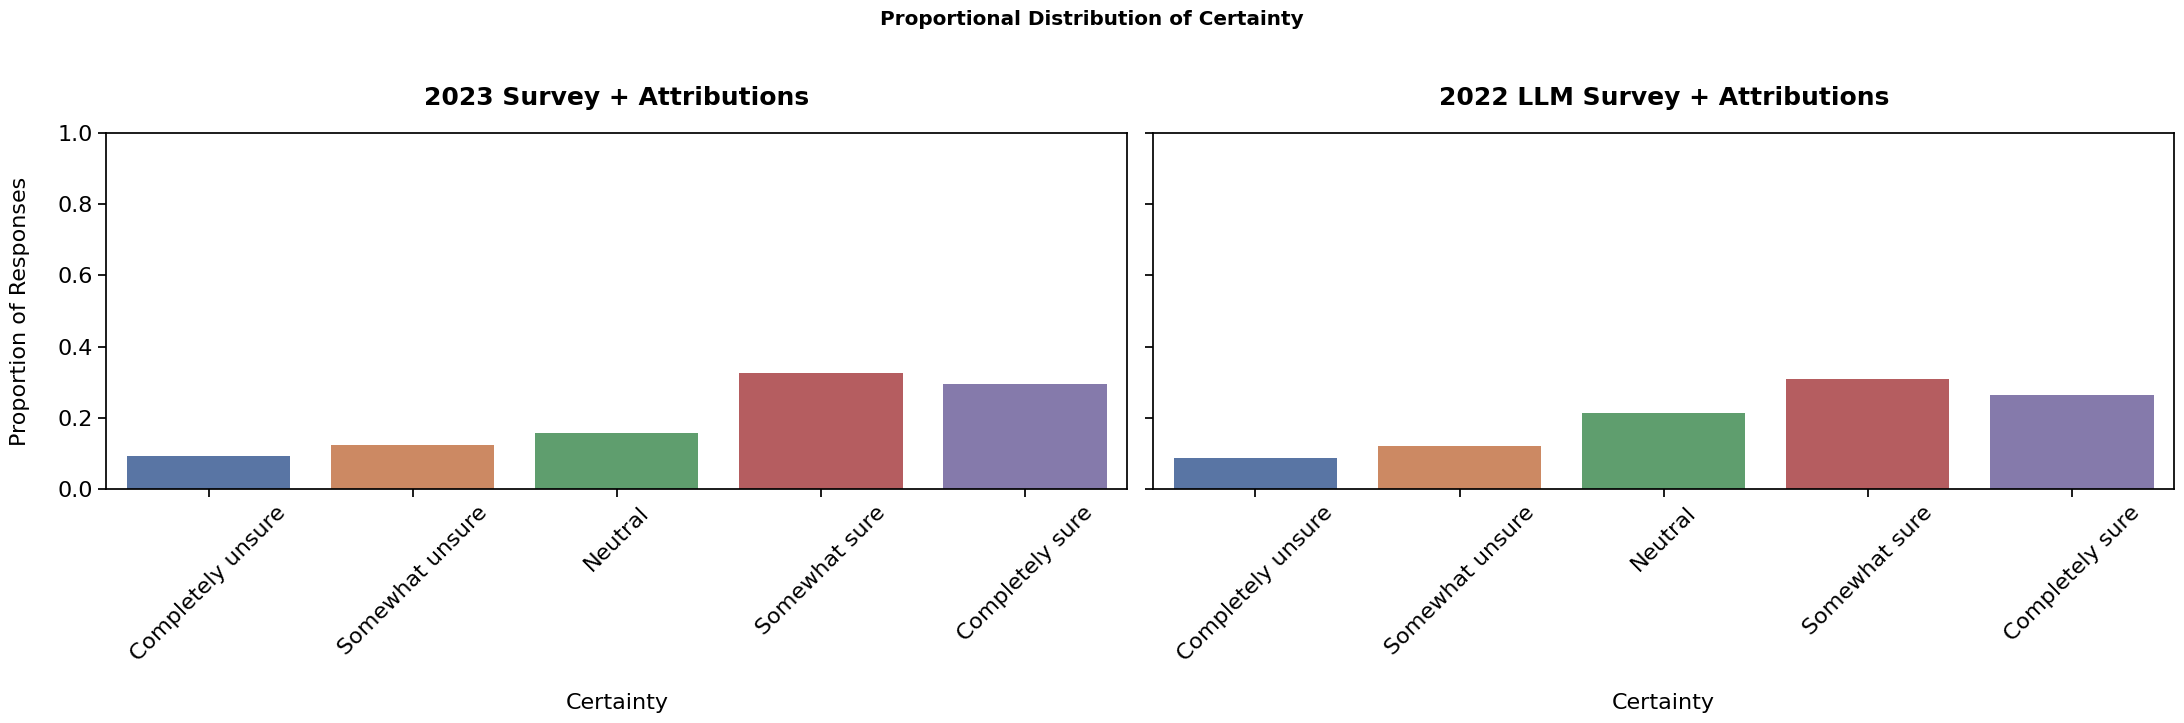

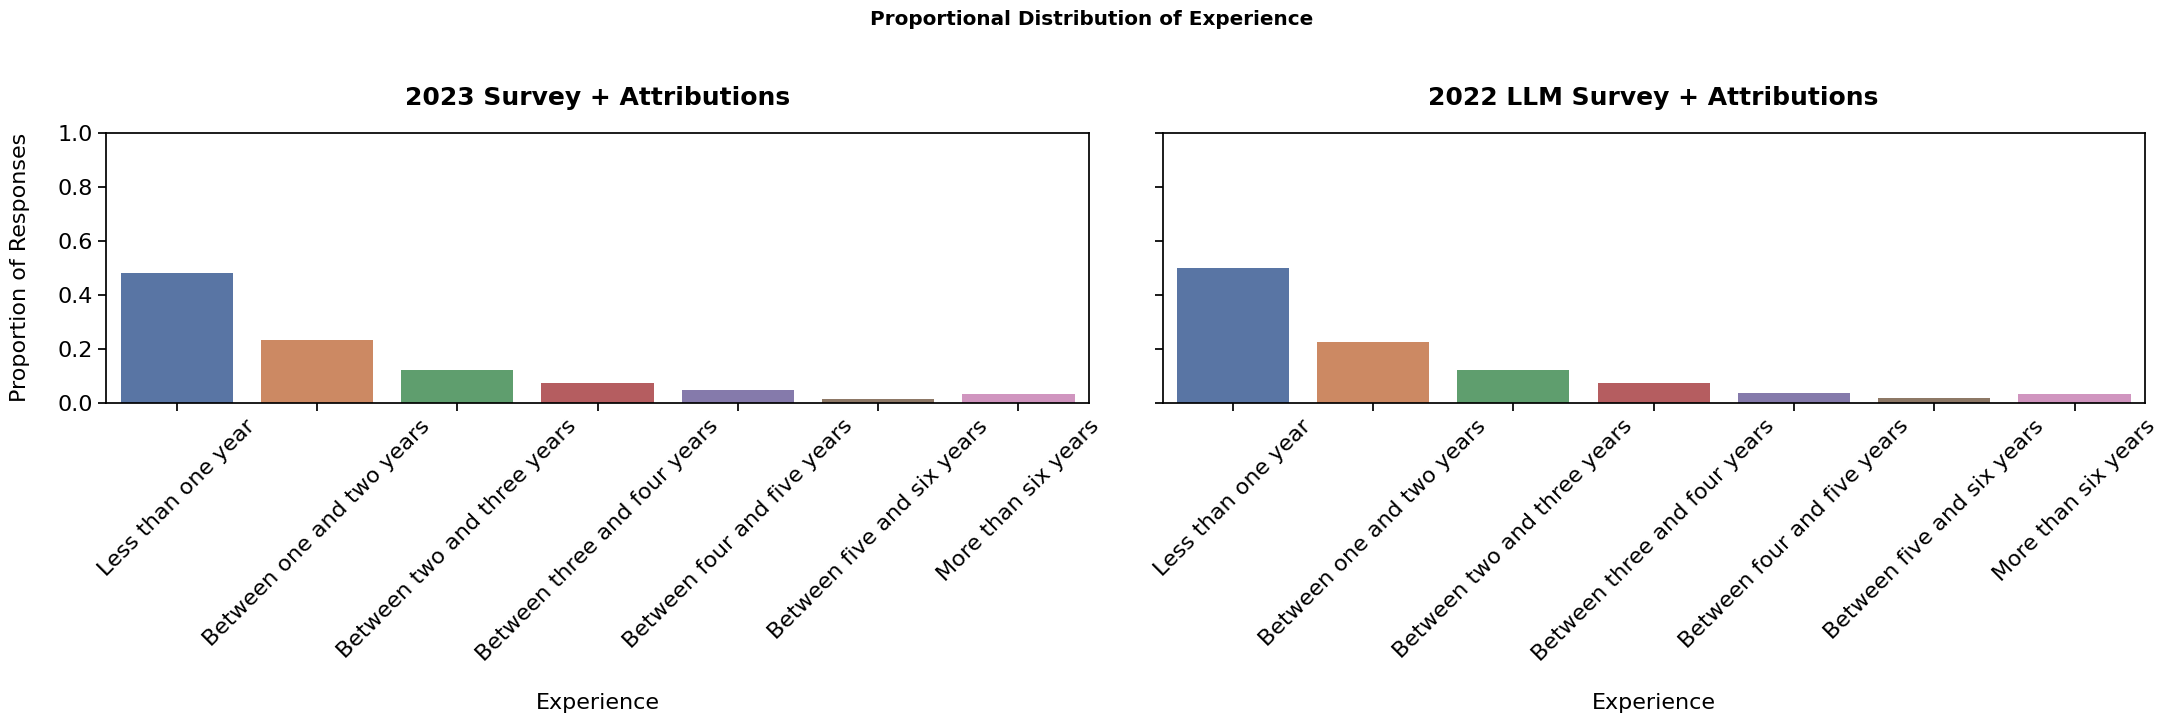

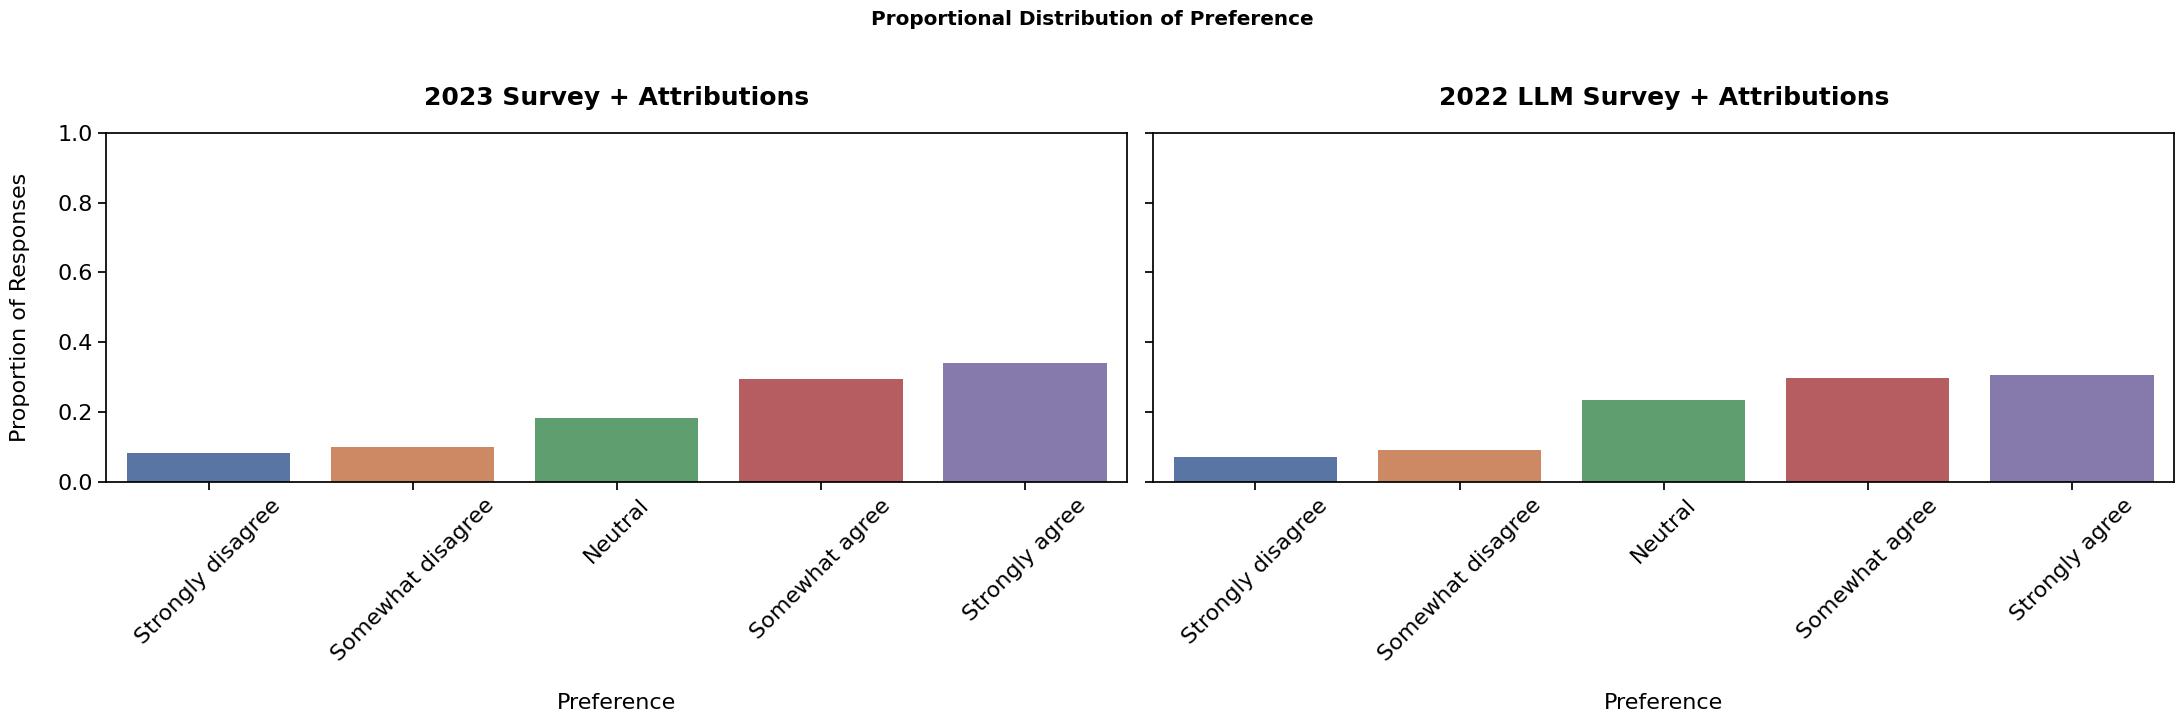

In [75]:
# Distribution of Certainty, Experience, and Preference answers: y axis is the proportion of responses

for col, order in category_orders.items():
    this_palette = {level: base_palette[i] for i, level in enumerate(order)}

    fig, axes = plt.subplots(1, 2, figsize=(22, 7), sharey=True)
    for ax, title in zip(axes, DATASET_ORDER):
        prop_df = (
            DATASETS[title][col]
            .value_counts(normalize=True)
            .reindex(order)
            .fillna(0.0)
            .rename_axis(col)
            .reset_index(name='Proportion')
        )

        sns.barplot(
            data=prop_df,
            x=col,
            y='Proportion',
            order=order,
            hue=col,
            palette=this_palette,
            dodge=False,
            legend=False,
            ax=ax,
        )

        ax.set_title(title)
        ax.set_xlabel(col)
        ax.set_ylabel('Proportion of Responses')
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle(f'Proportional Distribution of {col}', y=1.03, weight='bold')
    plt.tight_layout()
    plt.show()

When looking at all tasks (and not just the ones the people actually performed), most people are somewhat or completely certain of their knowledge in tasks, and most of them prefer them. Since students were targetted for the survey, most respondants have 1–2 years or less experience. We can see that the experience distribution looks like the 1/x or e^x distribution, so we can log it later when we convert it to ordinal numbers, to reduce right skew and approximate a more normal distribution. Applying a log transformation compresses higher levels (more years of experience) and expands lower levels (fewer years of experience), which makes differences among less experienced respondents clearer (between respondants with less than a year and respondants between 1-2 years of experience). This transformation may also improve our logistic regression by better identifying the nonlinear effect of experience on task performance (a difference between the first two experience categories might be bigger than the difference between the last two).

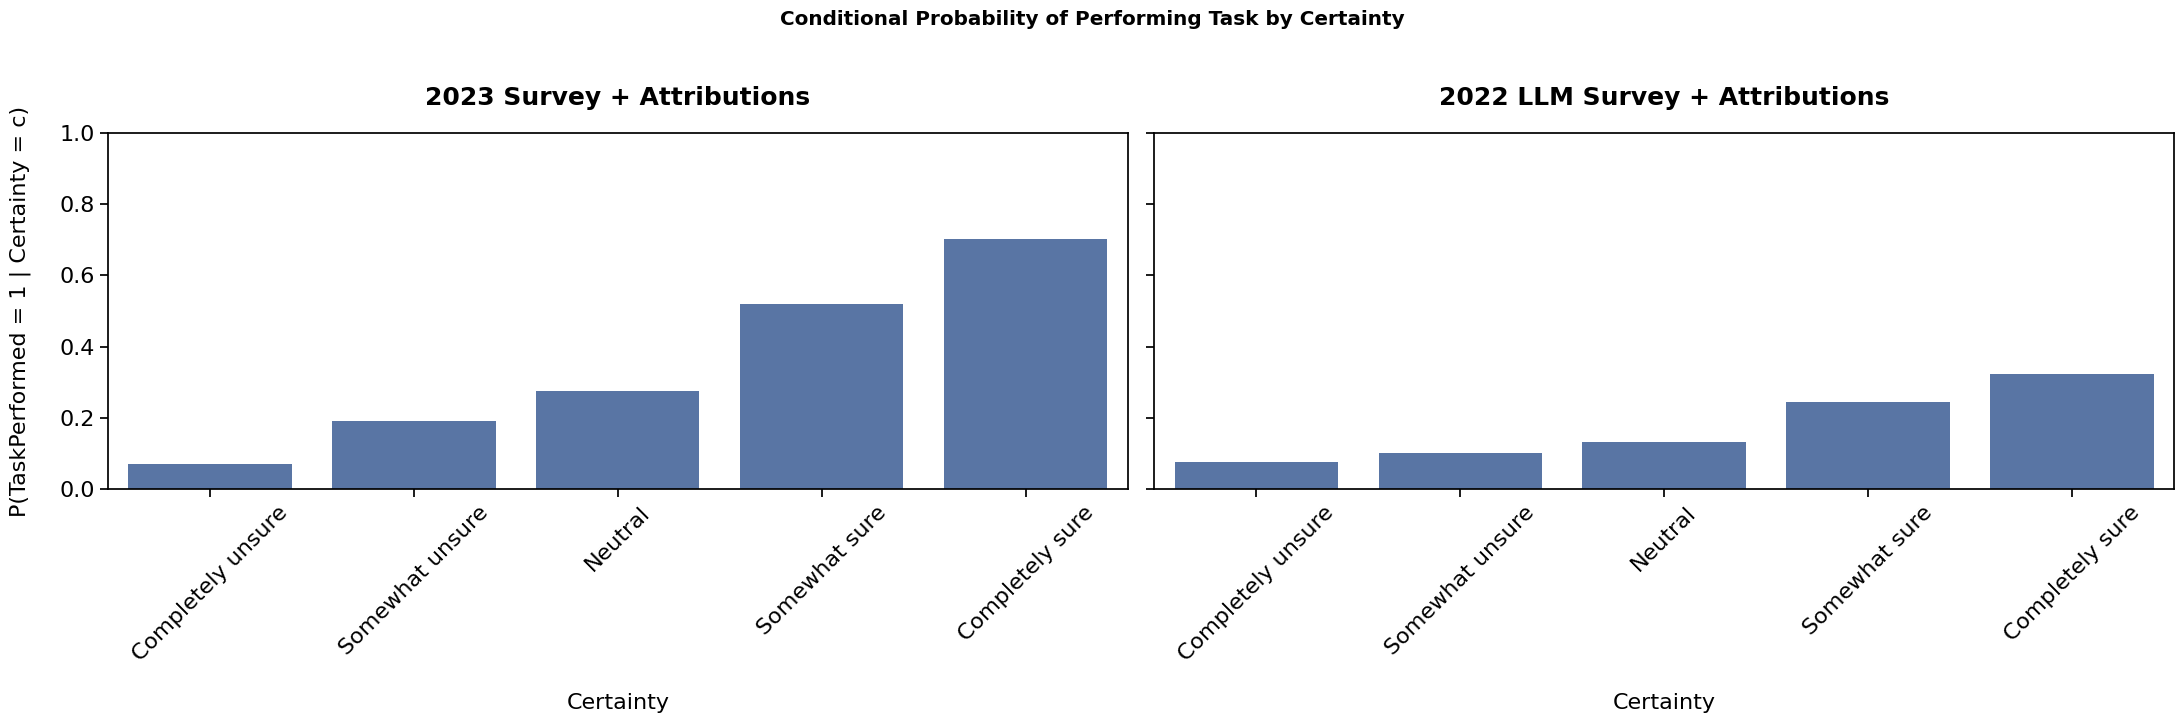

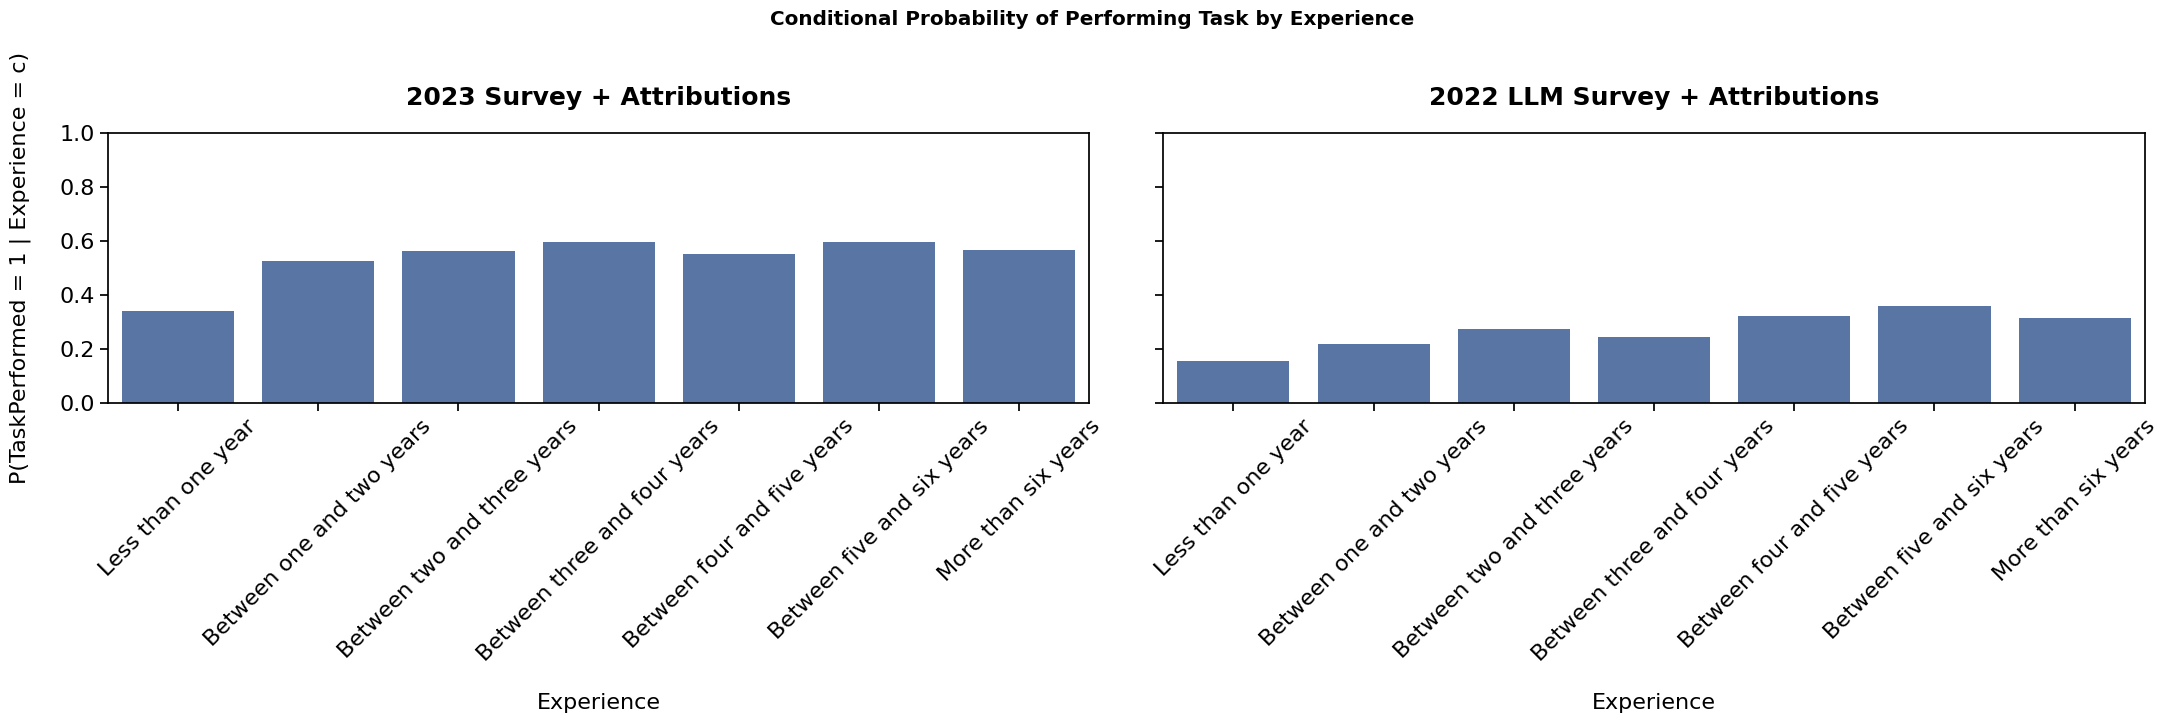

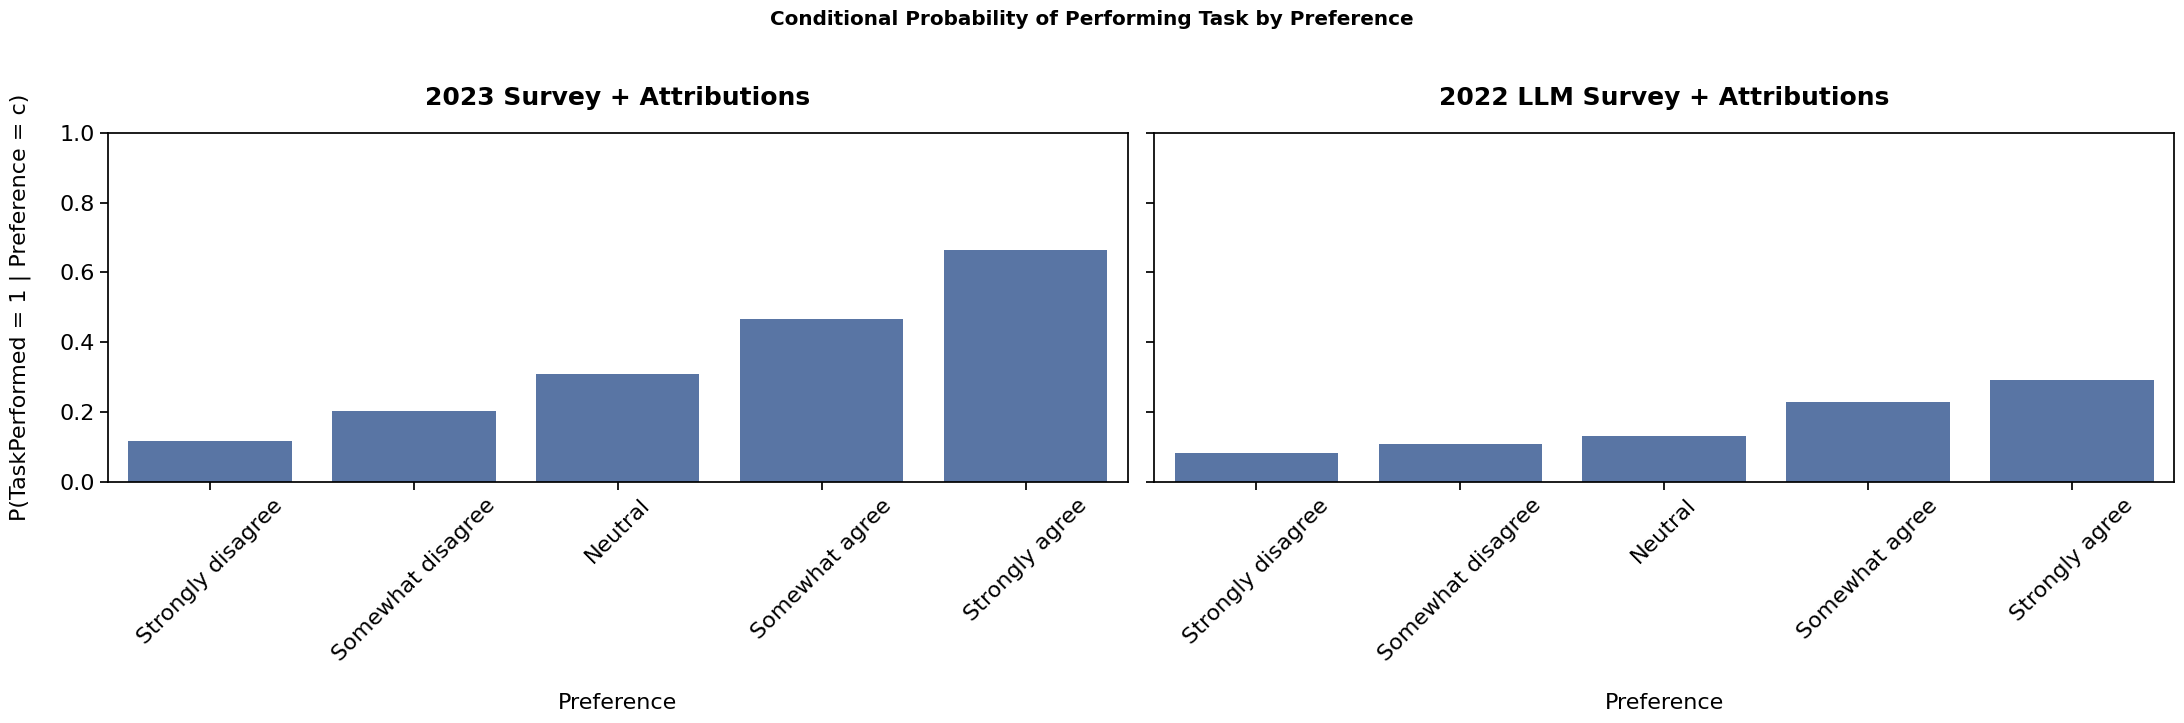

In [76]:
# Given that someone has a certain level of Certainty (or Experience, or Preference) c, how likely are they to perform the task?

# Conditional Probability - the probability of performing a task given a certain level of certainty, experience, or preference
# Independent bars that do not sum up to the probability of 1

for col in ['Certainty', 'Experience', 'Preference']:
    fig, axes = plt.subplots(1, 2, figsize=(22, 7), sharey=True)

    for ax, title in zip(axes, DATASET_ORDER):
        df2 = DATASETS[title].dropna(subset=['TaskPerformed']).copy()
        prob_df = (
            df2.groupby(col)['TaskPerformed']
            .mean()
            .reindex(category_orders[col])
            .reset_index()
            .rename(columns={'TaskPerformed': 'Probability'})
        )

        sns.barplot(data=prob_df, x=col, y='Probability', ax=ax)
        ax.set_ylim(0, 1)
        ax.set_title(title)
        ax.set_ylabel('P(TaskPerformed = 1 | ' + col + ' = c)')
        ax.set_xlabel(col)
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle(f'Conditional Probability of Performing Task by {col}', y=1.03, weight='bold')
    plt.tight_layout()
    plt.show()

The previous plots show the probability of actually performing a task, conditioned by the members' survey answers on certainty, experience, and preference. They each answer the question: "Given that someone has a certain level of Certainty (or Experience, or Preference) *c*, how likely are they to perform the task?" Tasks are significantly more likely to be performed as certainty increases, as the probability of performing a task that a person is completely unsure about is less than 0.1, while that probability goes up to ~0.6 if the person is completely sure in the task. Similarly, higher preference in the task associates with a higher probability of performing it. Experience does not quite effect the probability of a task being performed in higher categories (more than 2 years of experience), but it is important for people with less than one year and 1-2 experience. This means that the next survey should include more subcategories of these two (less than 6 months, 6 months - 1 year, etc). 

In [77]:
# Given that the task was performed, what’s the probability the person had certainty level c?

# Probability distribution of Certainty, Experience, and Preference levels among only those who performed the task, so the bars sum up to one
# Similar to the results of the distribution of responses, so it doesn't provide meaningful insights

# for col in ['Certainty', 'Experience', 'Preference']:
#     dist_df = (
#         df2[df2['TaskPerformed'] == 1]
#         .groupby(col)
#         .size()
#         .div(df2[df2['TaskPerformed'] == 1].shape[0])
#         .reindex(category_orders[col])
#         .reset_index(name='Probability')
#     )

#     sns.barplot(data=dist_df, x=col, y='Probability')
#     plt.ylim(0, 1)
#     plt.title(f'Distribution of {col} Levels Among Performed Tasks')
#     plt.ylabel('P(' + col + ' = c | TaskPerformed = 1)')
#     plt.xlabel(col)
#     plt.xticks(rotation=45, ha='right')
#     plt.tight_layout()
#     plt.show()

### 2.1 Student Members VS Student Leaders Distribution of Answers

- the most surveyed roles, so we analyze them seperately
- distribution of answers and probabilities of performing a task among students only

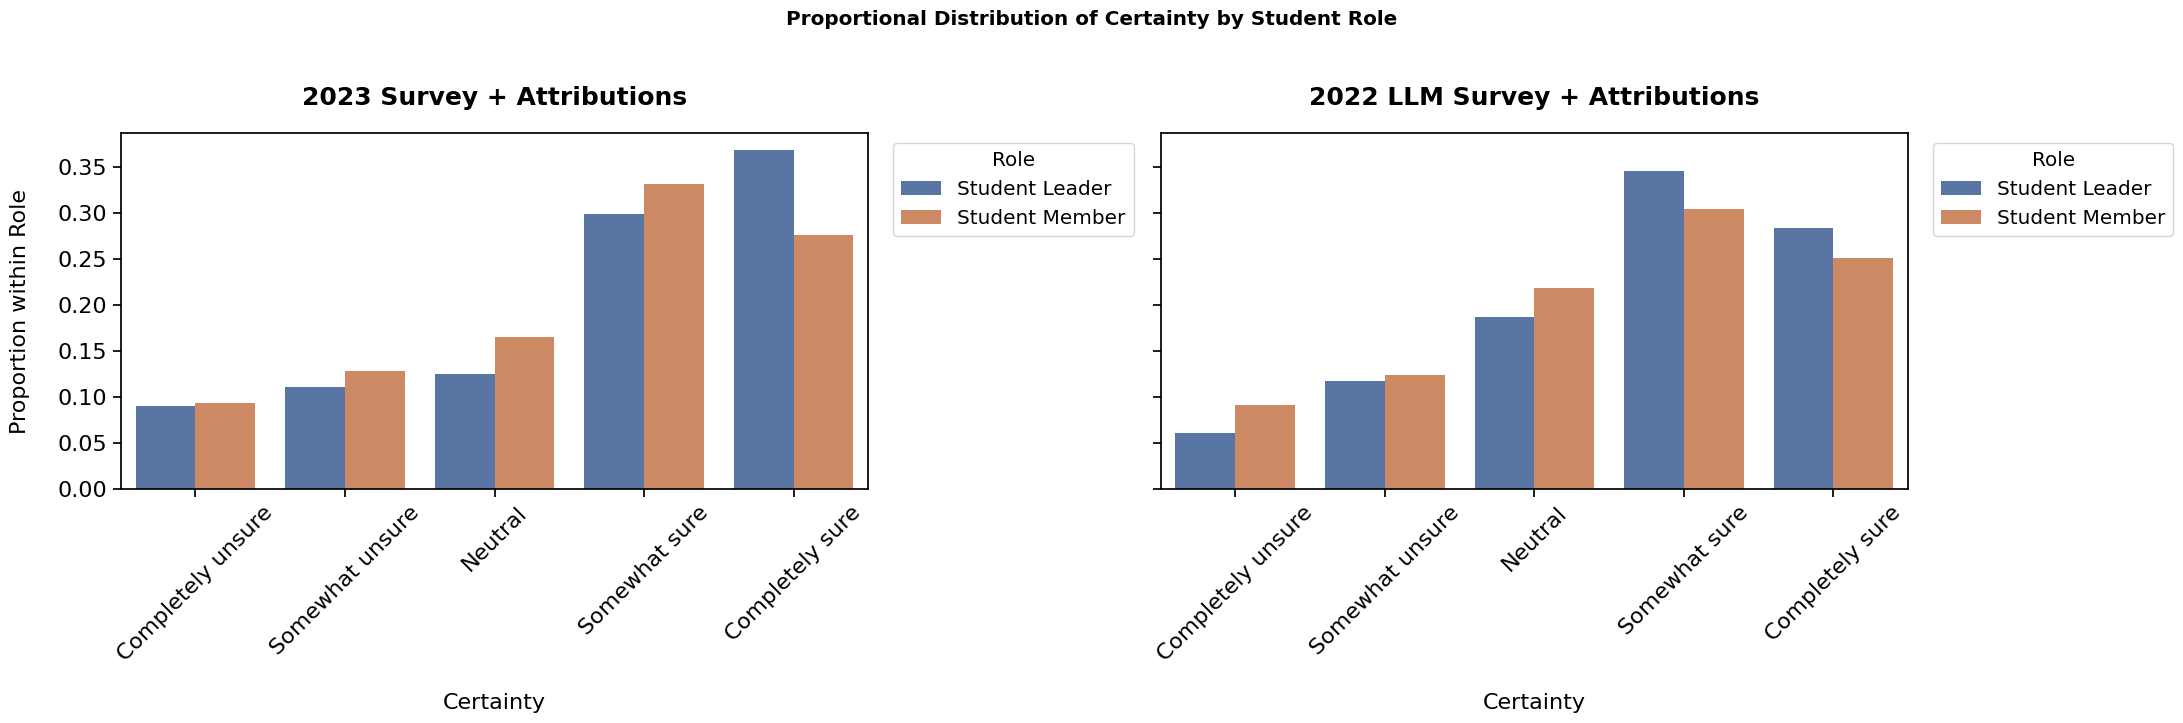

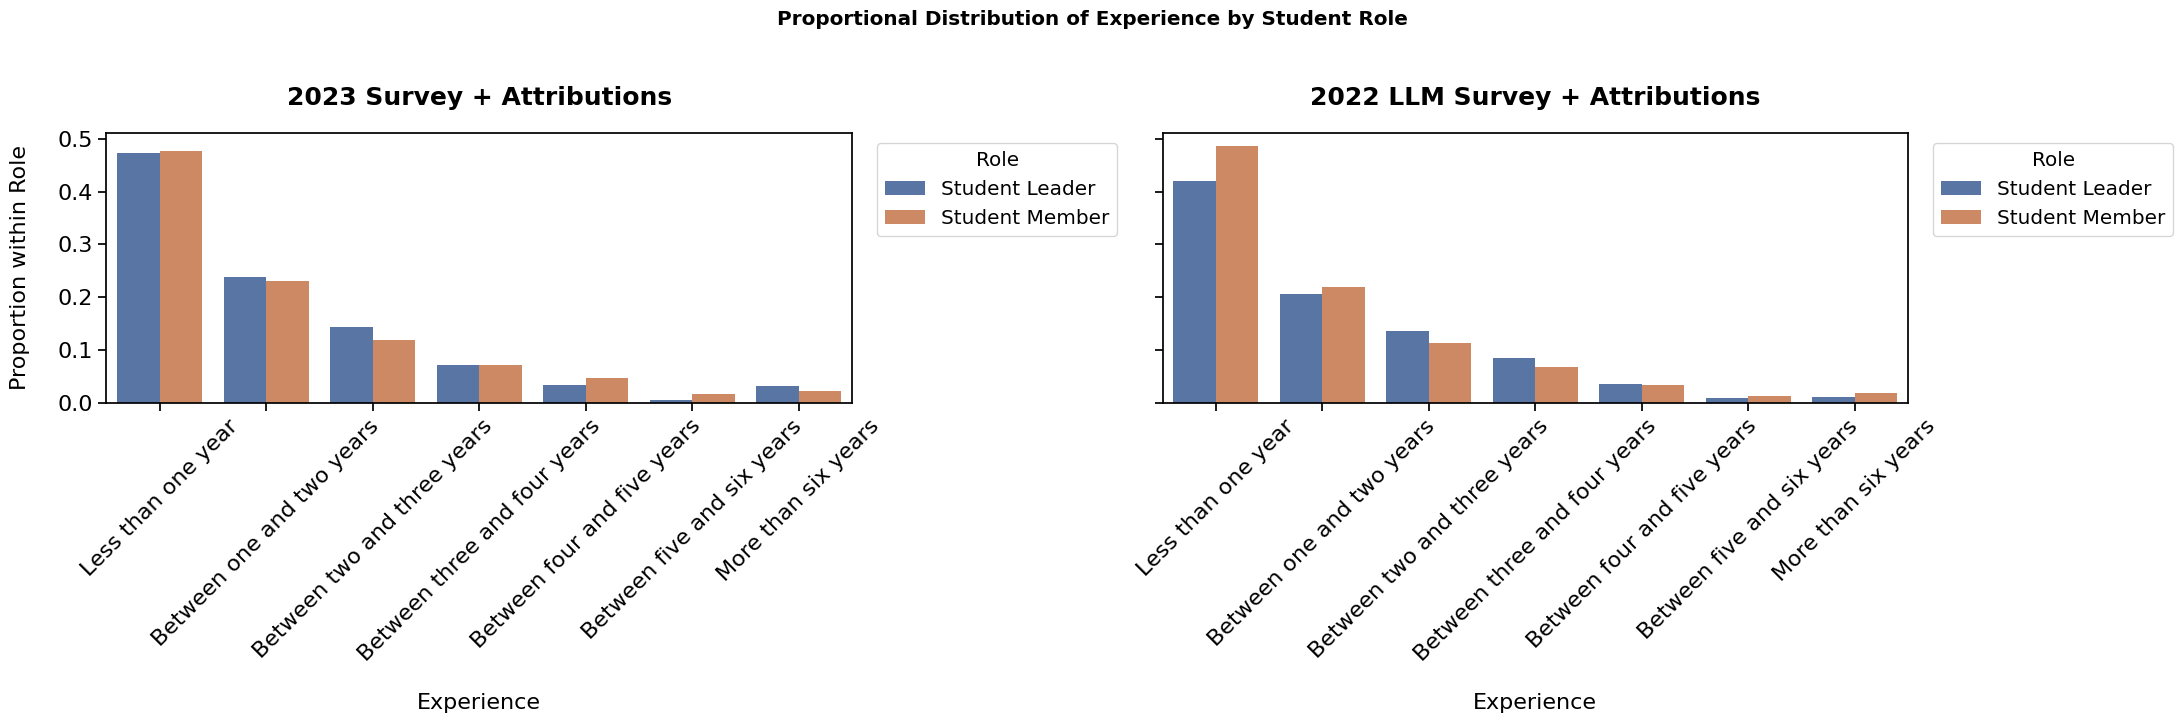

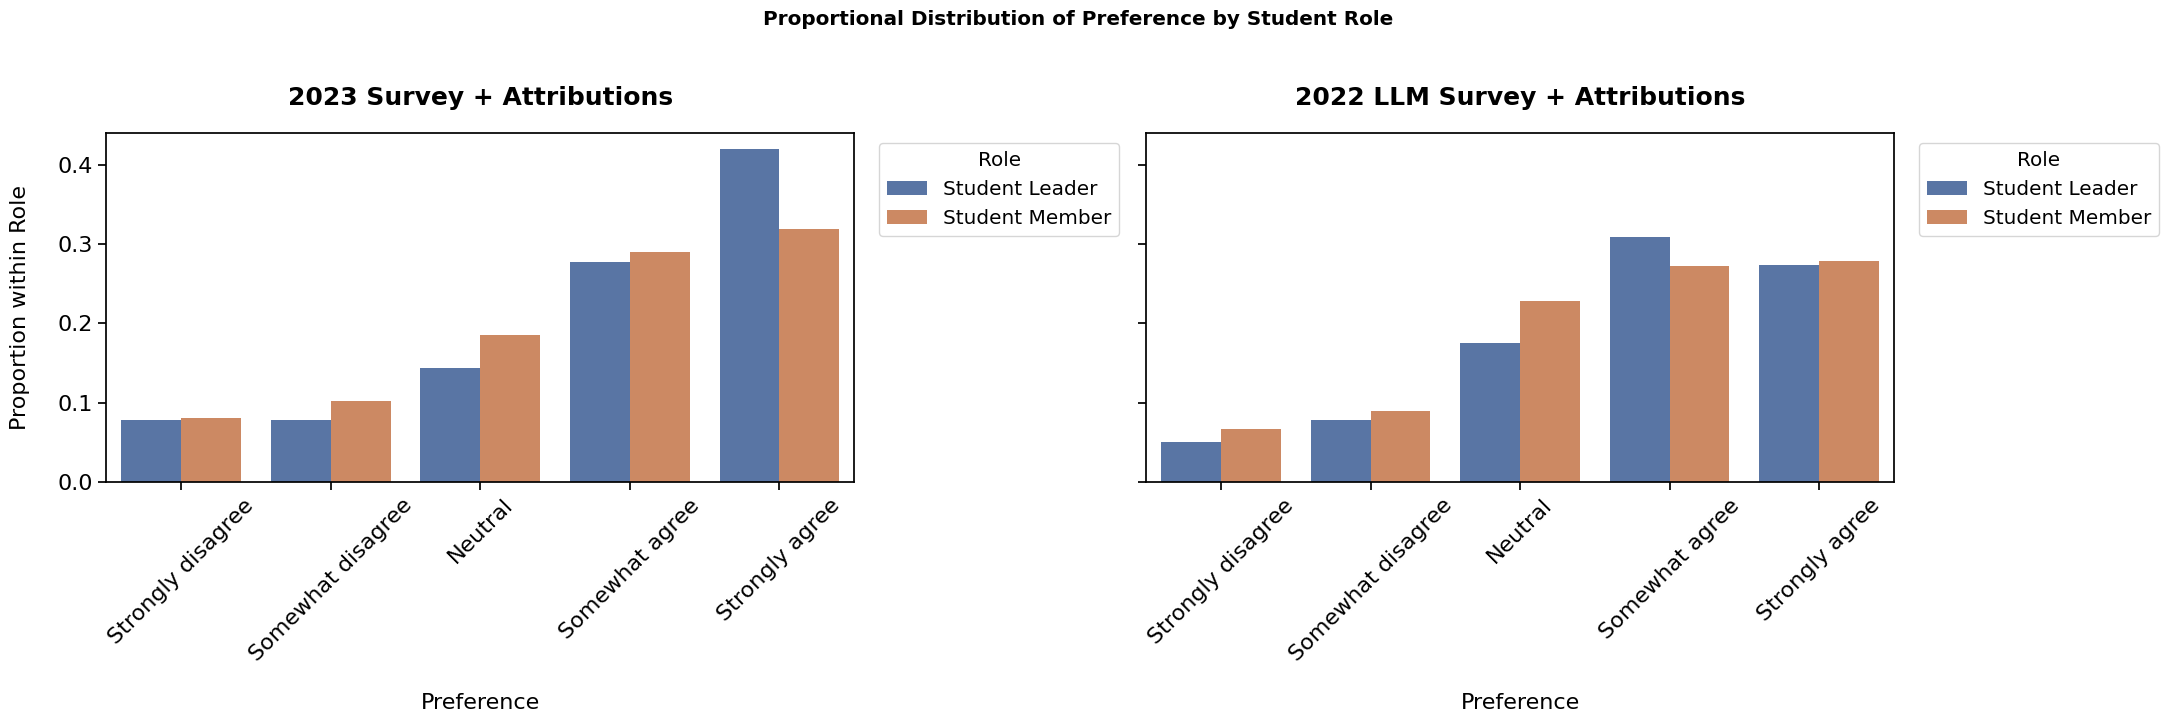

In [78]:
# Proportion within Student Member and Leader roles answering each question

for col, order in category_orders.items():
    fig, axes = plt.subplots(1, 2, figsize=(22, 7), sharey=True)

    for ax, title in zip(axes, DATASET_ORDER):
        df2 = DATASETS[title].dropna(subset=['Role']).copy()
        df2['Role'] = df2['Role'].str.strip()
        df2 = df2[df2['Role'].isin(['Student Member', 'Student Leader'])]

        counts = (
            df2.groupby(['Role', col])
            .size()
            .reset_index(name='Count')
        )

        totals = (
            df2['Role']
            .value_counts()
            .rename_axis('Role')
            .reset_index(name='Total')
        )

        merged = counts.merge(totals, on='Role')
        merged['Proportion'] = merged['Count'] / merged['Total']
        merged[col] = pd.Categorical(merged[col], categories=order, ordered=True)
        merged = merged.sort_values(by=col)

        sns.barplot(
            data=merged,
            x=col,
            y='Proportion',
            hue='Role',
            ax=ax,
        )

        ax.set_title(title)
        ax.set_ylabel('Proportion within Role')
        ax.set_xlabel(col)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(
            title='Role',
            bbox_to_anchor=(1.02, 1),
            loc='upper left',
            title_fontsize='large',
            fontsize='large'
        )

    plt.suptitle(f'Proportional Distribution of {col} by Student Role', y=1.03, weight='bold')
    plt.tight_layout()
    plt.show()

**How are the responses to Certainty, Experience and Preference distributed among Student Members and Student Leaders, and how do these distributions differ proportionally between the two roles?**

The proportional distributions of answers are pretty similar between the two student roles. However, the proportion of student leaders answering "Completely sure" and "Strongly agree" to Certaintu and Preference questions is higher than that proportion among student members. We will look at the distribution of probabilities of performing a task between the two roles. This shows legitimacy of the student leaders - they are sure and like more tasks.

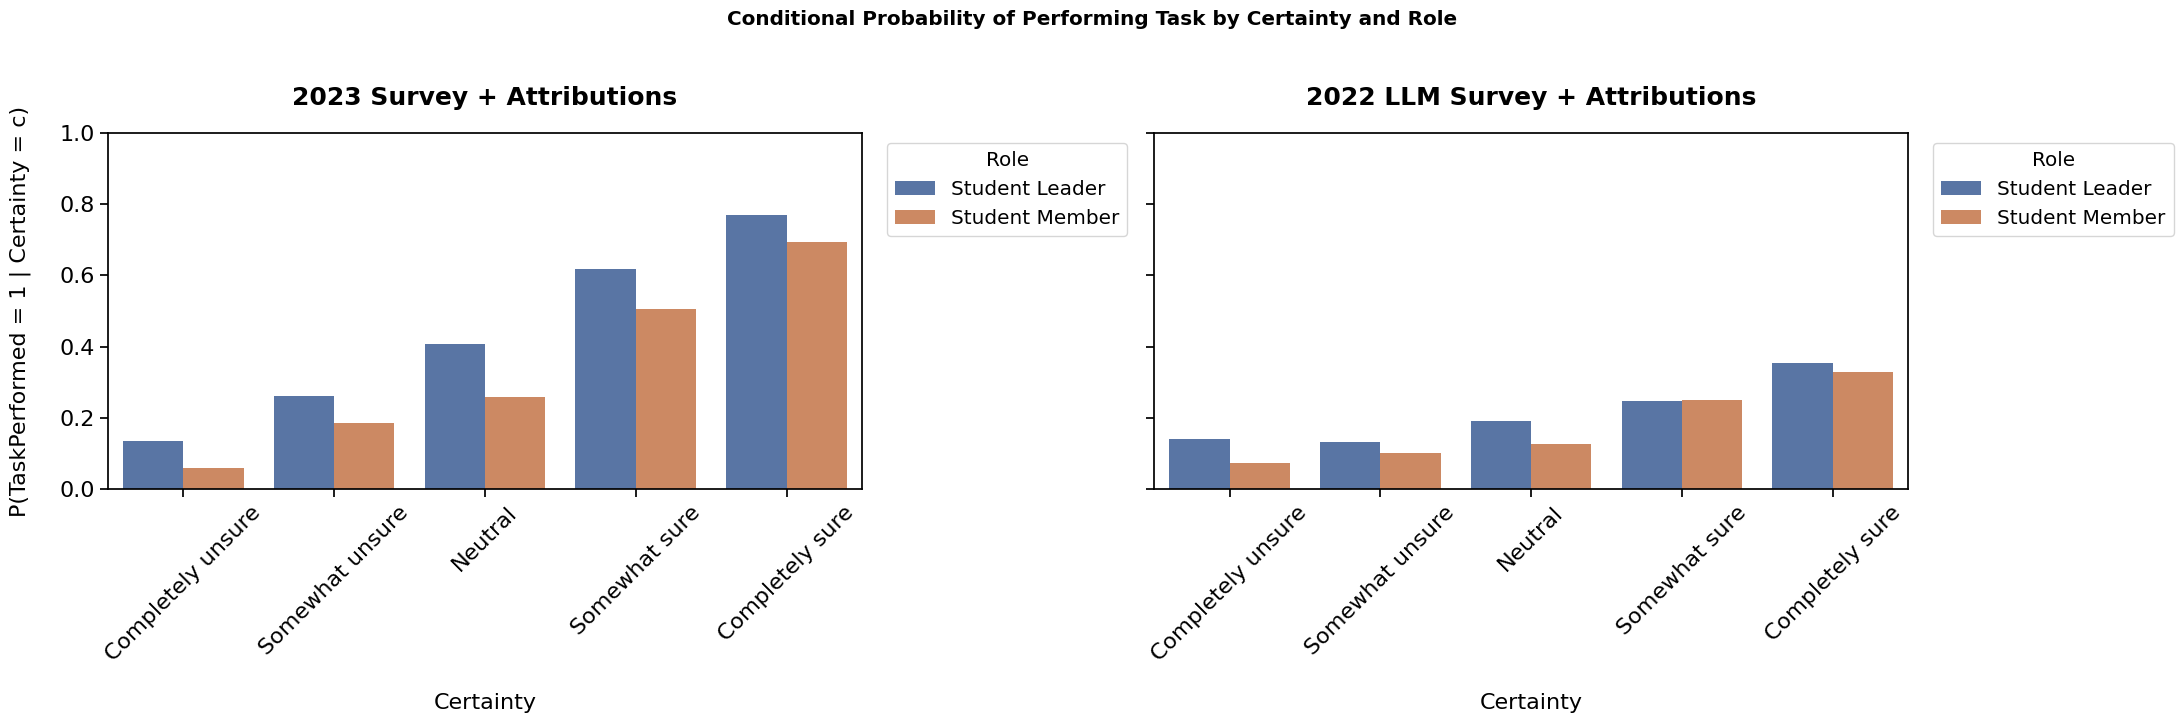

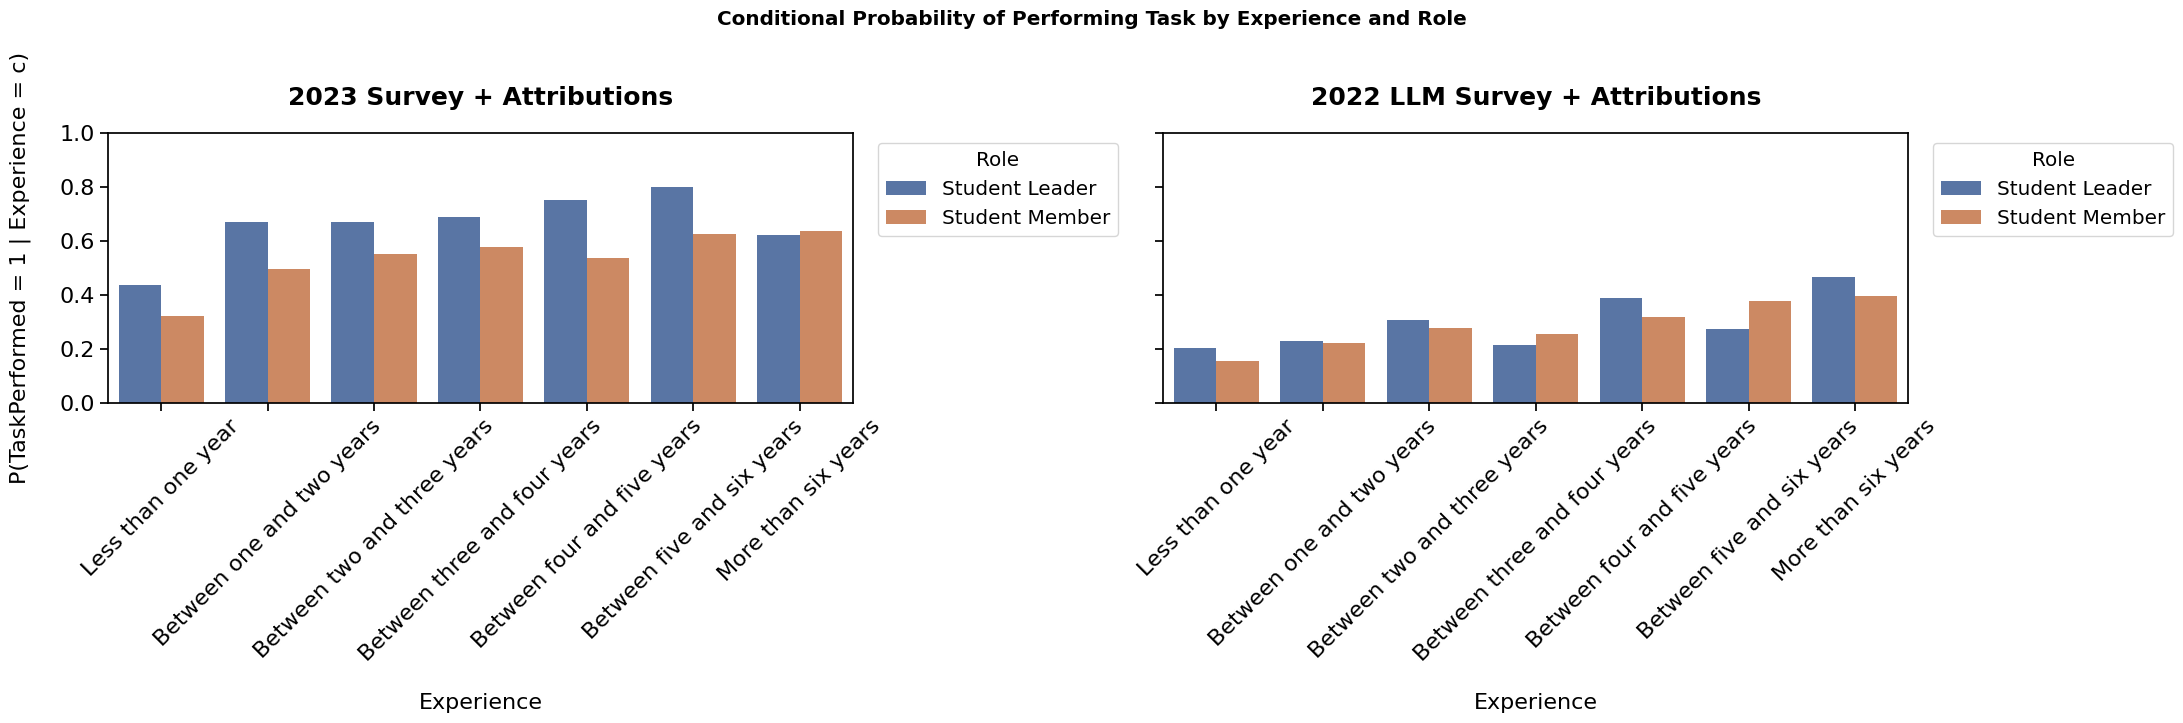

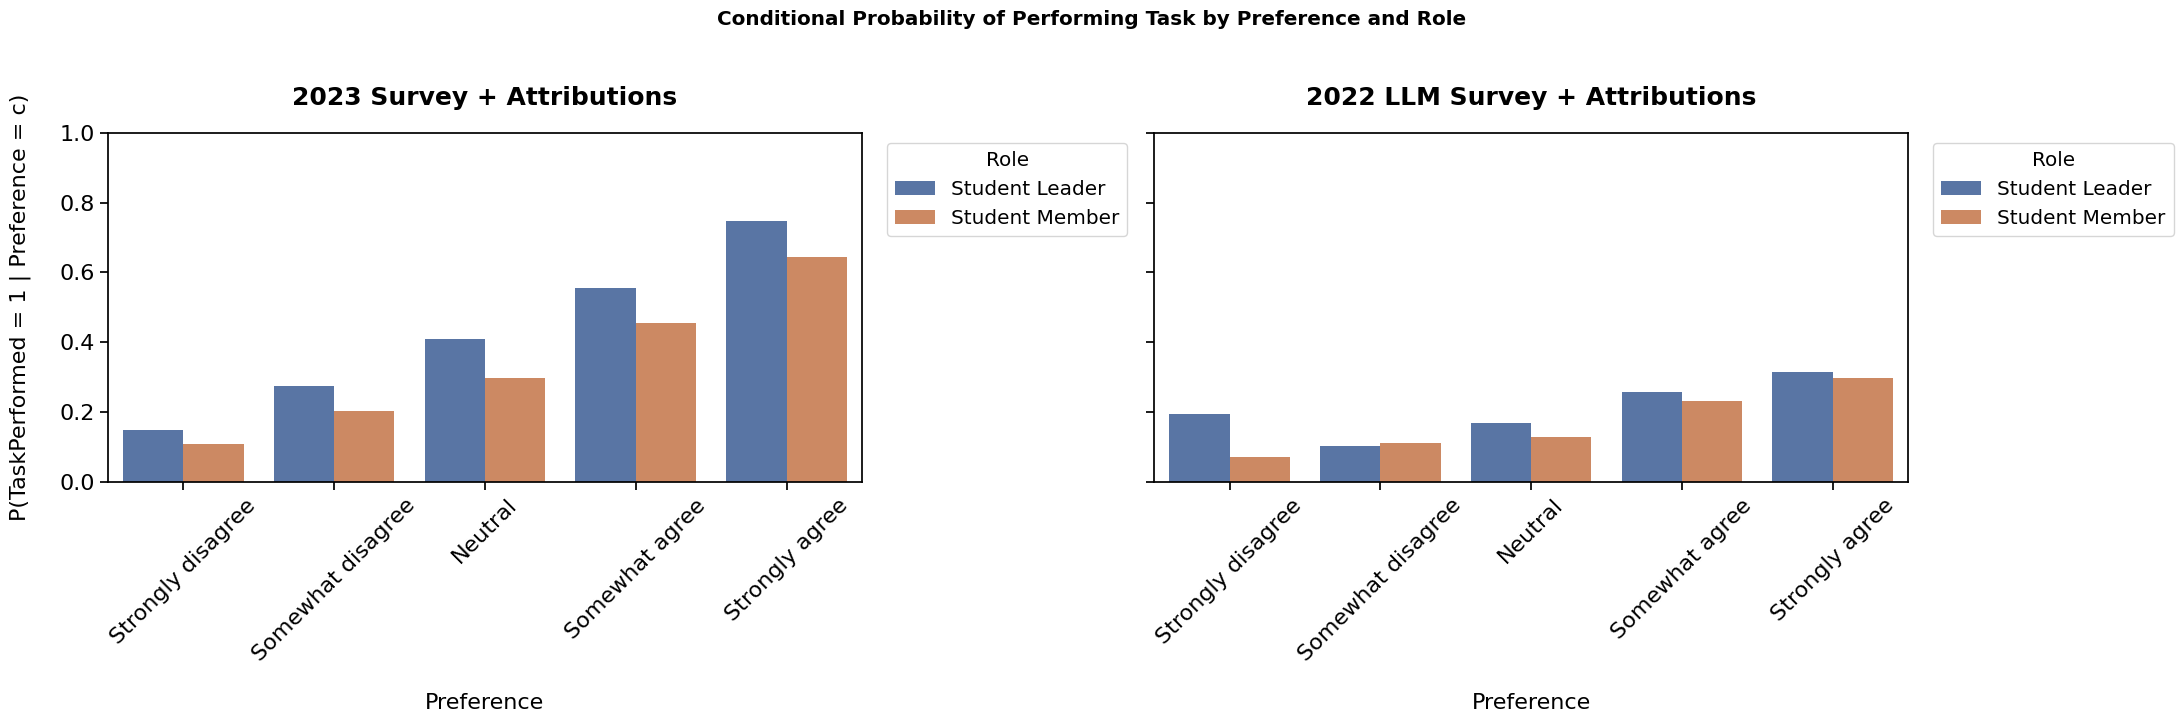

In [79]:
# Conditional Probability of performing the task by Certainty, Experience, and Preference within Student Member and Leader roles

for col in ['Certainty', 'Experience', 'Preference']:
    fig, axes = plt.subplots(1, 2, figsize=(22, 7), sharey=True)

    for ax, title in zip(axes, DATASET_ORDER):
        df2 = DATASETS[title].dropna(subset=['Role', 'TaskPerformed']).copy()
        df2['Role'] = df2['Role'].str.strip()
        df2 = df2[df2['Role'].isin(['Student Member', 'Student Leader'])]

        prob_df = (
            df2.groupby(['Role', col])['TaskPerformed']
            .mean()
            .reset_index()
            .rename(columns={'TaskPerformed': 'Probability'})
        )

        prob_df[col] = pd.Categorical(prob_df[col], categories=category_orders[col], ordered=True)
        prob_df = prob_df.sort_values(by=col)

        sns.barplot(
            data=prob_df,
            x=col,
            y='Probability',
            hue='Role',
            ax=ax,
        )

        ax.set_ylim(0, 1)
        ax.set_title(title)
        ax.set_ylabel('P(TaskPerformed = 1 | ' + col + ' = c)')
        ax.set_xlabel(col)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(
            title='Role',
            bbox_to_anchor=(1.02, 1),
            loc='upper left',
            title_fontsize='large',
            fontsize='large'
        )

    plt.suptitle(f'Conditional Probability of Performing Task by {col} and Role', y=1.03, weight='bold')
    plt.tight_layout()
    plt.show()

For all categories and answers, student leaders are more probable to perform a task (except slightly higher probability of student members with more than 6 years of experience - which is not a lot of data points anyways). These conditional probabilities are computed within each Certainty/Experience/Preference level, not across them, so they do not sum to 1, each bar is independent to the others. For example: among Student Leaders who are completely sure about a task, around 70% actually performed it, while that number is around 60% for Student Members. Similarly, among leaders who are somewhat sure, nearly 60% performed the task, or around 50% from Student Members.

## 3. Data Conversion to Ordinals
- convert Certainty, Experience, and Preference data to ordinals 

In [80]:
# Convert Certainty, Experience, and Preference to ordinal codes

# Build mapping dicts from category_orders
ordinal_encodings = {
    col: { level: idx + 1 for idx, level in enumerate(order) }
    for col, order in category_orders.items()
}

survey_and_attributions_ordinals_df = survey_and_attributions_df.copy()

# Replace original columns with their 1-based ordinal codes
for col in ['Certainty', 'Experience', 'Preference']:
    survey_and_attributions_ordinals_df[col] = (
        survey_and_attributions_df[col]
        .map(ordinal_encodings[col])
        .astype('Int64')  # preserves nulls
    )

In [81]:
survey_and_attributions_ordinals_df.head()

,Team,TeamMember,Role,Task,Certainty,Experience,Preference,TaskPerformed
0,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Analysis,2,2,3,0
1,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Background Research,4,2,3,1
2,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Conceptualization,3,1,3,1
3,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Data Curation,2,1,2,0
4,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Entrepreneurship,3,1,2,0


In [82]:
survey_and_attributions_ordinals_df.to_csv("../results/survey_tasks_and_attributions/2023_survey_tasks_and_attributions_ordinal.tsv", sep="\t", index=False)

## 4. Task Survey Category Comparison

- for each task survey category, plot boxplot (best for ordinal and not continuous data) comparing values between task performed and task not performed 
- compute wilcoxon test and p-value for each column with task attribution (0 or 1)
- analyze log experience 

In [83]:
# Drop null values

final_survey_attributions_df = survey_and_attributions_ordinals_df.dropna()

In [84]:
final_survey_attributions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6082 entries, 0 to 7094
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Team           6082 non-null   object
 1   TeamMember     6082 non-null   object
 2   Role           6082 non-null   object
 3   Task           6082 non-null   object
 4   Certainty      6082 non-null   Int64 
 5   Experience     6082 non-null   Int64 
 6   Preference     6082 non-null   Int64 
 7   TaskPerformed  6082 non-null   Int64 
dtypes: Int64(4), object(4)
memory usage: 451.4+ KB


In [85]:
# Wilcoxon test funct

def compute_wilcoxon(df, col):
    group0 = df.loc[df['TaskPerformed'] == 0, col]
    group1 = df.loc[df['TaskPerformed'] == 1, col]
    return mannwhitneyu(group0, group1, alternative='two-sided')

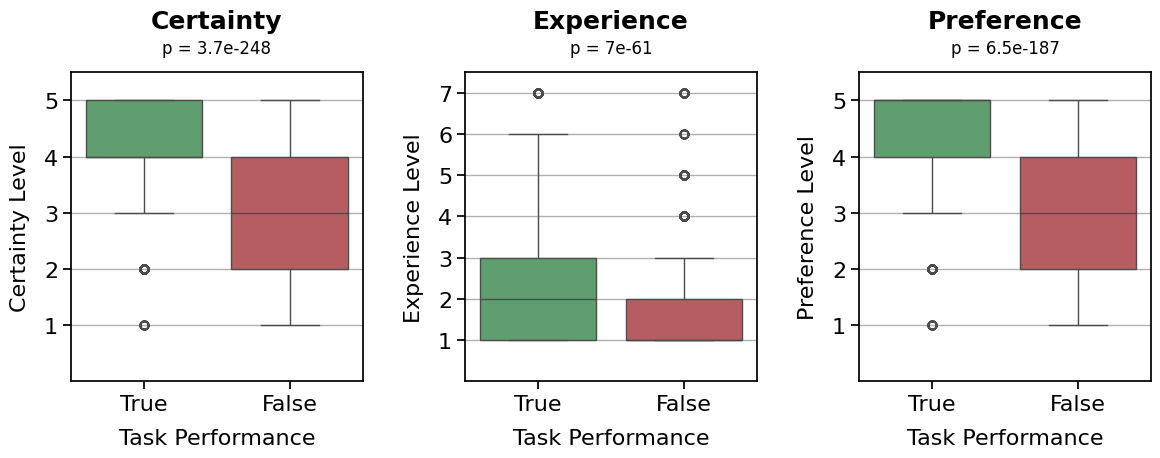

In [86]:
with plt.rc_context({'axes.labelpad': 10}):
    fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=False)

    for i, (ax, col) in enumerate(zip(axes, ['Certainty', 'Experience', 'Preference'])):
        _, p_value = compute_wilcoxon(final_survey_attributions_df, col)

        ordered_df = final_survey_attributions_df.copy()
        ordered_df['TaskPerformed'] = ordered_df['TaskPerformed'].map({1: 'Performed', 0: 'Not Performed'})
        ordered_df['TaskPerformed'] = pd.Categorical(ordered_df['TaskPerformed'], categories=['Performed', 'Not Performed'], ordered=True)

        sns.boxplot(
            data=ordered_df,
            x='TaskPerformed',
            y=col,
            hue='TaskPerformed',
            palette={'Not Performed': base_palette[3], 'Performed': base_palette[2]},
            legend=False,
            ax=ax
        )

        ax.set_title(f'{col}', pad=32)
        ax.set_xlabel('Task Performance')
        ax.set_ylabel(f'{col} Level')
        ax.grid(False, axis='x')

        max_level = len(category_orders[col])
        ax.set_yticks(range(1, max_level + 1))
        ax.set_ylim(0, max_level + 0.5)
        ax.grid(True, axis='y')

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['True', 'False'])

        ax.text(
            0.5, 1.05,
            f"p = {p_value:.2g}",
            ha='center',
            va='bottom',
            transform=ax.transAxes,
            fontsize=12
        )

    plt.subplots_adjust(wspace=6, hspace=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


All three variables show statistically significant differences in distributions between those who performed the task and those who didn’t. On Certainty boxplot we can see a clear separation - those who performed the task show higher certainty (median = 5) vs non-performers (median = 3). Preference is similar in that case, while the separation is less clear in Experience. There are a couple of outliers in each category.

In [87]:
# Wilcoxon tests for each ordinal survey category
for col in ['Certainty', 'Experience', 'Preference']:
    stat, p_value = compute_wilcoxon(final_survey_attributions_df, col)
    print(f"{col}: U = {stat:.2f}, p-value = {p_value:.2g}")

Certainty: U = 2365332.00, p-value = 3.7e-248
Experience: U = 3528914.50, p-value = 7e-61
Preference: U = 2665800.50, p-value = 6.5e-187


In each case the null hypothesis (“The distribution of certainty/experience/preference scores is the same for people who actually attributed to the task and those who did not.”) is rejected with p value close to 0 in each one. This tells us that actual attribution to a task correlates with higher confidence, more experience, and bigger preference for that task. Certainty and Preference have the strongest visual and statistical impact, while Experience has a bigger p-value compared to them (though still very small). The *U* statistic counts the number of times a value from one group exceeds a value from the other (task performed or not).

## 5. Correlation Matrix & Heatmap
- correlation heatmap between the ordinal columns and TaskPerformed
- per role analysis (compare just student members with student leaders)

### 5.1 Correlation between Certainty, Experience, Preference and Task Performance

In [40]:
# Correlation Matrix between 'Certainty', 'Experience', 'Preference' and 'TaskPerformed' 
# function can be used to plot for dataframes of different meber roles

def plot_correlation_heatmap(df_subset, title=None):

    cols = ['Certainty', 'Experience', 'Preference', 'TaskPerformed']
    corr_df = df_subset[cols].dropna()

    # Compute correlation and p-value matrices
    corr_matrix = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols)
    p_matrix = corr_matrix.copy()

    for i, col_i in enumerate(cols):
        for j, col_j in enumerate(cols):
            if j >= i:
                corr, p = spearmanr(corr_df[col_i], corr_df[col_j])
                corr_matrix.loc[col_i, col_j] = corr_matrix.loc[col_j, col_i] = corr
                p_matrix.loc[col_i, col_j] = p_matrix.loc[col_j, col_i] = p

    # Create annotations with significance stars
    annot = corr_matrix.copy().astype(str)
    for i in cols:
        for j in cols:
            p = p_matrix.loc[i, j]
            if p < 0.001:
                stars = '***'
            elif p < 0.01:
                stars = '**'
            elif p < 0.05:
                stars = '*'
            else:
                stars = ''
            annot.loc[i, j] = f"{corr_matrix.loc[i, j]:.2f}{stars}" if stars else ''
    np.fill_diagonal(annot.values, '')

    # Mask: upper triangle and non-significant values
    mask_sig = (p_matrix >= 0.05)
    np.fill_diagonal(mask_sig.values, False)
    mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    mask = mask_sig | mask_upper

    # Plot
    # Replace diagonal values with 0 and use a diverging cmap that renders 0 as grey
    corr_matrix_for_plot = corr_matrix.copy()
    np.fill_diagonal(corr_matrix_for_plot.values, 0)

    sns.heatmap(
        corr_matrix_for_plot,
        mask=mask,
        annot=annot,
        fmt='',
        cmap=sns.diverging_palette(240, 10, as_cmap=True),  # ensures 0 = grey
        center=0,
        cbar_kws={'label': "Spearman’s Correlation Coefficient"}
    )

    if title:
        plt.title(title, fontweight='bold')

    plt.tight_layout()
    plt.show()

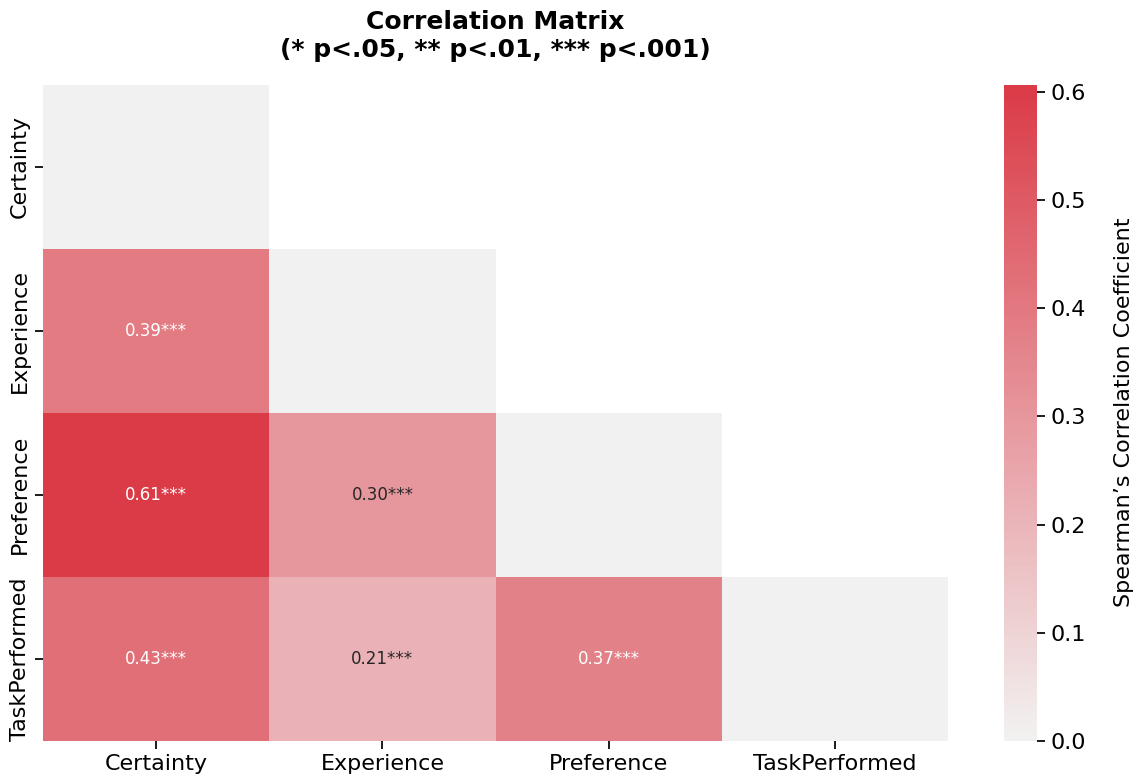

In [41]:
plot_correlation_heatmap(
    final_survey_attributions_df,
    title="Correlation Matrix\n(* p<.05, ** p<.01, *** p<.001)"
)

The previous graph shows correlations between the 3 ordinal columns and the binary TaskPerformed column. All of them have a significant p-value, as the heatmap was annotated with stars (* < 0.05, ** < 0.01, *** < 0.001). Spearman's correlation coefficient is the highest between Preference and Certainty, and is 0.6, meaning that colienarity exists between the predictors (keep in mind when creating a linear regression model). The correlation coefficient between Certainty and TaskPerformed is equal to 0.39, and a little less between Preference and TaskPerformed.

### 5.2 Student Member VS Student Leader Correlation Analysis

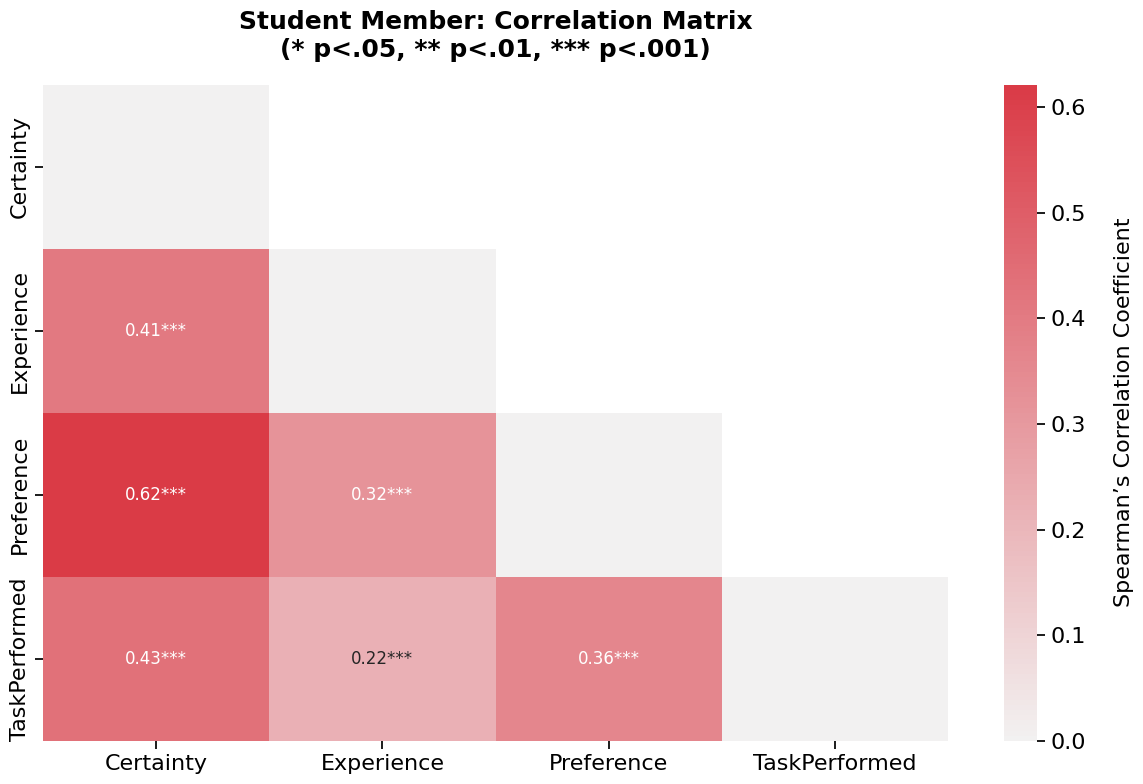

In [42]:
plot_correlation_heatmap(
    final_survey_attributions_df[final_survey_attributions_df['Role'] == 'Student Member'],
    title="Student Member: Correlation Matrix\n(* p<.05, ** p<.01, *** p<.001)"
)

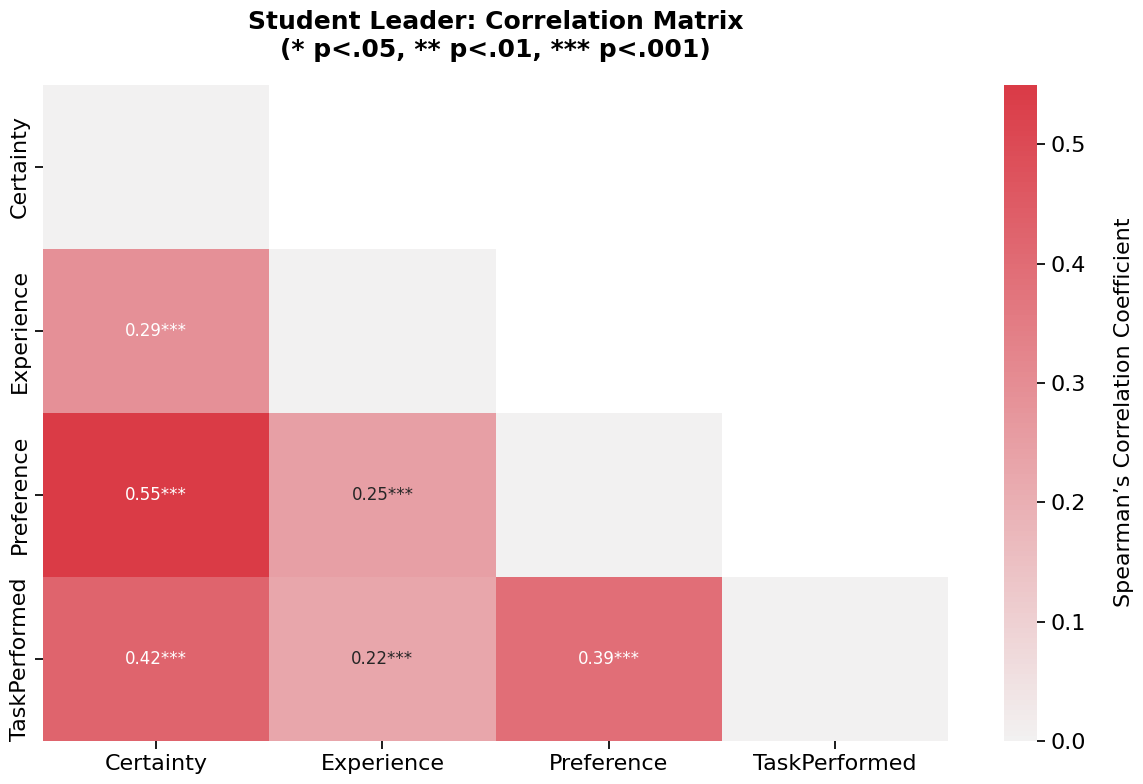

In [43]:
plot_correlation_heatmap(
    final_survey_attributions_df[final_survey_attributions_df['Role'] == 'Student Leader'],
    title="Student Leader: Correlation Matrix\n(* p<.05, ** p<.01, *** p<.001)"
)

All correlations within both student roles are very significant and similar between each other. Preference and TaskPerformed show a slightly stronger association among Student Leaders. On the other side, the correlations between the ordinal survey measures themselves (e.g., Certainty vs. Experience, Certainty vs. Preference) are lower among Student Leaders than Student Members, possibly indicating more independent self-assessments among leaders.

### 5.3 Logistic Regression Modeling

- ordinal predictors: Certainty, Experience, and Preference
- binary outcome: TaskPerformed

In [44]:
# Can add LogExperience to the predictors as well, just log that column first

final_survey_attributions_df = final_survey_attributions_df.copy()
final_survey_attributions_df['LogExperience'] = np.log1p(final_survey_attributions_df['Experience'])

In [45]:
final_survey_attributions_df.head()

,Team,TeamMember,Role,Task,Certainty,Experience,Preference,TaskPerformed,LogExperience
0,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Analysis,2,2,3,0,1.098612
1,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Background Research,4,2,3,1,1.098612
2,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Conceptualization,3,1,3,1,0.693147
3,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Data Curation,2,1,2,0,0.693147
4,ABOA-Turku,172d6820fb71f042f13fb7e22ffd437221944e3757ff20...,Student Leader,Entrepreneurship,3,1,2,0,0.693147


In [46]:
# Logistic Regression Model to predict TaskPerformed based on Certainty, Experience, and Preference


predictors = ["Certainty", "Preference", "Experience", "LogExperience"]
outcome = "TaskPerformed"

scaler = StandardScaler() # mean=0,standard deviation=1
final_survey_attributions_df[predictors] = scaler.fit_transform(final_survey_attributions_df[predictors])


# Function to fit logistic regression models
def fit_logit_models(outcome, predictors, df):
    formulas = [f"{outcome} ~ {p}" for p in predictors]
    models = []
    
    for formula in formulas:
        model = smf.logit(formula=formula, data=df).fit()
        models.append(model)
    return models, formulas


# Fubnction to print model summaries
def print_model_summaries(models, formulas):
    for i, (model, formula) in enumerate(zip(models, formulas), start=1):
        print(f"\n=== Summary for model {i}: {formula} ===\n")
        print(model.summary())

        # Calculate and print odds ratios with CI
        print("\n--- Odds Ratios and 95% CI ---")
        odds_ratios = np.exp(model.params)
        conf_int = np.exp(model.conf_int())
        or_table = (
            pd.DataFrame({
                'Odds Ratio': odds_ratios,
                'CI Lower': conf_int[0],
                'CI Upper': conf_int[1]
            })
        )
        print(or_table)


# Function for plotting coefficient estimate model comparison with CI
def plot_model_comparison(models, formulas, outcome,
                          fig_size=(10,6), tick_label_size=12,
                          xlabel_size=14, ylabel_size=14,
                          title_size=18, capsize=0, marker_size=8):
    # Extract coefficients and SEs
    coef_df = pd.DataFrame({
        f"model{i+1}": m.params.drop("Intercept")
        for i, m in enumerate(models)
    }).T

    se_df = pd.DataFrame({
        f"model{i+1}": m.bse.drop("Intercept")
        for i, m in enumerate(models)
    }).T

    # 95% confidence intervals (instead of SE)
    ci95_df = se_df * 1.96

    variables = coef_df.columns.tolist()
    n_models = len(models)
    y_pos = np.arange(len(variables))

    plt.figure(figsize=fig_size)
    for i, model_name in enumerate(coef_df.index):
        plt.errorbar(
            coef_df.loc[model_name].values,
            y_pos,
            xerr=ci95_df.loc[model_name].values,  # 95% CI
            fmt='o',
            capsize=capsize,
            markersize=marker_size,
            label=model_name,
            elinewidth=1,
            markeredgewidth=1
        )

    plt.yticks(y_pos, variables, fontsize=tick_label_size)
    plt.axvline(0, color='grey', linewidth=1, linestyle='--')
    plt.title(f"Model Comparison for {outcome.capitalize()}",
              fontsize=title_size, fontweight='bold')
    plt.xlabel("Estimate", fontsize=xlabel_size, fontweight='bold')
    plt.ylabel("Parameter", fontsize=ylabel_size, fontweight='bold')
    plt.legend(ncol=2, fontsize="small", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(False)
    plt.tight_layout()
    plt.show()


In [47]:
models, formulas = fit_logit_models(outcome, predictors, final_survey_attributions_df)

Optimization terminated successfully.
         Current function value: 0.586046
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.614083
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.673314
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.669032
         Iterations 4


In [48]:
print_model_summaries(models, formulas)


=== Summary for model 1: TaskPerformed ~ Certainty ===

                           Logit Regression Results                           
Dep. Variable:          TaskPerformed   No. Observations:                 6082
Model:                          Logit   Df Residuals:                     6080
Method:                           MLE   Df Model:                            1
Date:                Sat, 16 May 2026   Pseudo R-squ.:                  0.1486
Time:                        22:45:27   Log-Likelihood:                -3564.3
converged:                       True   LL-Null:                       -4186.5
Covariance Type:            nonrobust   LLR p-value:                1.453e-272
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2956      0.029    -10.036      0.000      -0.353      -0.238
Certainty      1.0637      0.035     30.561      0.000       0.995       1

Certainty and Preference are strong predictors of whether a task is performed. Each 1-point increase in Certainty more than doubles the odds of performing a task (odds ratio ≈ 2.12), while a 1-point increase in Preference nearly doubles the odds (odds ratio ≈ 1.91). Both predictors are highly significant with narrow confidence intervals. Experience also significantly increases the odds (odds ratio ≈ 1.24), but the effect is smaller. The model with Certainty explains the most variation in task performance (pseudo R^2 ~ 0.12), followed by Preference (~0.09), while Experience explains very little (~0.02). All p-values are very low which means that all 3 models are statistically significant. The LogExperience model is better than the Experience one (bigger pseudo R^2, odds ratio, smaller LLR p-value), suggesting that early experience strongly increases the chance of performing a task, while the effect on TaskPerformed is less with more years of experience (because log transformation gives more importance to lower numbers). 

Therefore, team members (mostly students cause they filled out the survey) tend to perform tasks they like and are confident in, while their experience in a task matters a little less.

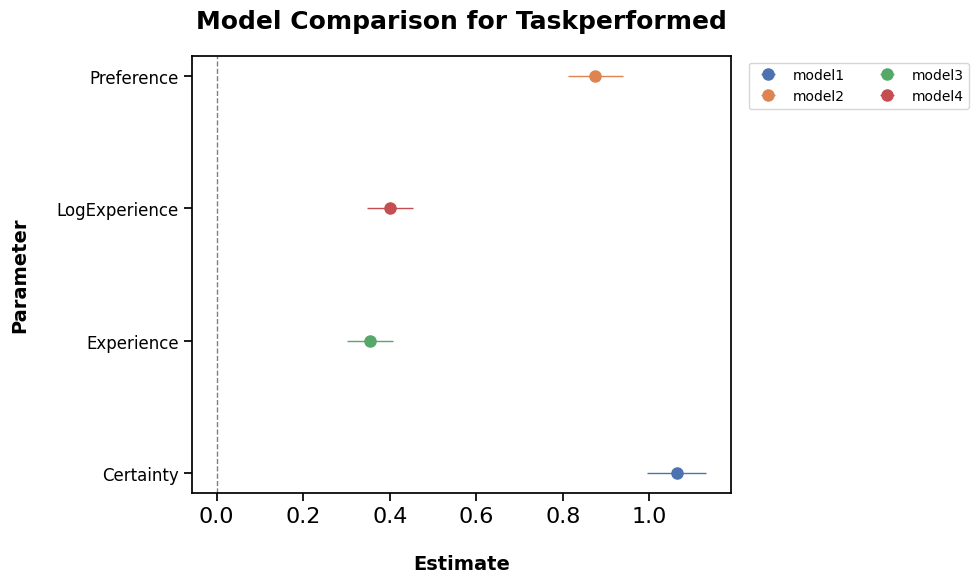

In [49]:
plot_model_comparison(models, formulas, outcome)

Similar conclusions as before: the further away the logistic regression estimate from *x + 0*, the stronger its effect on task performance. Wider confidence intervals, as in LogExperience, suggest greater uncertainty in that effect.

In [50]:
# Modeling of TaskPerformed for different tasks separately


# column names 
def clean_task_name(name: str) -> str:
    return re.sub(r'[^0-9A-Za-z]+', '', str(name))

# Unique tasks
tasks = final_survey_attributions_df["Task"].dropna().unique()

task_models = {}

# Start the output df with the Predictor column
result_cols = ["Predictor"]
result_df = pd.DataFrame({"Predictor": predictors})

for task in tasks:
    task_mask = final_survey_attributions_df["Task"] == task
    df_task = final_survey_attributions_df.loc[task_mask].copy()

    # If no variation in the outcome for this task, fill columns with NaN and continue
    est_col = f"{clean_task_name(task)}Estimate"
    pval_col = f"{clean_task_name(task)}PValue"
    result_cols.extend([est_col, pval_col])

    if df_task[outcome].nunique() < 2:
        result_df[est_col] = np.nan
        result_df[pval_col] = np.nan
        print(f"Skipping task '{task}' – only one outcome value present.")
        continue

    # Fit one model per predictor and extract the coefficient and p-value for that predictor
    est_map = {}
    pval_map = {}
    fitted_models_for_task = []

    for p in predictors:
        formula = f"{outcome} ~ {p}"
        m = smf.logit(formula=formula, data=df_task).fit(disp=False)
        m.task_name = task
        m.predictor = p
        fitted_models_for_task.append(m)

        # Extract the predictor's coefficient and p-value (exclude Intercept) 
        est_map[p] = m.params[p]
        pval_map[p] = m.pvalues[p]

    task_models[task] = fitted_models_for_task

    result_df[est_col]  = result_df["Predictor"].map(est_map)
    result_df[pval_col] = result_df["Predictor"].map(pval_map)

# Reorder columns so Predictor comes first, then each task’s Estimate/PValue pair
result_df = result_df[result_cols]

result_df = result_df.copy()
for c in result_df.columns:
    if c != "Predictor":
        result_df[c] = result_df[c].astype(float).round(4)

# result_df now has columns like:
# Predictor, Task1NameEstimate, Task1NamePValue, Task2NameEstimate, Task2NamePValue, ...
result_df


,Predictor,AnalysisEstimate,AnalysisPValue,BackgroundResearchEstimate,BackgroundResearchPValue,ConceptualizationEstimate,ConceptualizationPValue,DataCurationEstimate,DataCurationPValue,EntrepreneurshipEstimate,...,PublicEngagementEstimate,PublicEngagementPValue,SafetyEstimate,SafetyPValue,SoftwareEstimate,SoftwarePValue,VisualizationEstimate,VisualizationPValue,WritingEstimate,WritingPValue
0,Certainty,0.7660,0.0000,0.9608,0.0000,0.6792,0.0000,0.5946,0.0000,1.0431,...,0.9392,0.0000,0.6143,0.0000,1.4522,0.0000,0.4918,0.0001,0.3918,0.0160
1,Preference,0.5828,0.0000,0.5584,0.0000,0.4641,0.0023,0.3837,0.0016,0.7181,...,0.7336,0.0000,0.5266,0.0001,1.1477,0.0000,0.5513,0.0000,0.6244,0.0000
2,Experience,0.1126,0.2549,0.0389,0.7129,0.1268,0.2324,0.1157,0.2697,0.0673,...,0.1037,0.2941,0.1665,0.1558,0.5063,0.0001,0.1037,0.2317,-0.0113,0.9129
3,LogExperience,0.1569,0.1155,0.0684,0.5328,0.1223,0.2585,0.1624,0.1180,0.1434,...,0.1155,0.2376,0.1844,0.1031,0.5779,0.0000,0.1134,0.2153,0.0275,0.8064


In [51]:
# Plotting results as heatmap

def plot_task_heatmap_from_df(result_df, figsize=(12,6), font_scale=0.9, annot_fontsize=10):
    sns.set_context("notebook", font_scale=font_scale)

    estimate_cols = [c for c in result_df.columns if c.endswith("Estimate")]
    pvalue_cols   = [c for c in result_df.columns if c.endswith("PValue")]
    tasks = [c.replace("Estimate", "") for c in estimate_cols]

    df = result_df.set_index("Predictor")
    beta = pd.DataFrame({t: df[f"{t}Estimate"] for t in tasks})
    pval = pd.DataFrame({t: df[f"{t}PValue"]   for t in tasks})

    def p_to_stars(p):
        if pd.isna(p):   return ""
        if p < 0.001:    return "***"
        elif p < 0.01:   return "**"
        elif p < 0.05:   return "*"
        else:            return ""

    annot = pd.DataFrame('', index=beta.index, columns=beta.columns, dtype=object)
    for r in annot.index:
        for c in annot.columns:
            b = beta.loc[r, c]
            p = pval.loc[r, c]
            annot.loc[r, c] = "" if pd.isna(b) else f"{b:.2f}{p_to_stars(p)}"

    beta_for_plot = beta.copy()
    non_sig = (pval.isna()) | (pval >= 0.05)
    beta_for_plot[non_sig] = beta_for_plot[non_sig] * 0.25

    vmin = np.nanmin(beta_for_plot.values)
    vmax = np.nanmax(beta_for_plot.values)
    abs_max = max(abs(vmin), abs(vmax)) if np.isfinite(vmin) and np.isfinite(vmax) else 1.0

    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        beta_for_plot,
        annot=annot,
        fmt="",
        cmap="RdBu_r",
        norm=TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max),
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Logit Coefficient (β)"},
        annot_kws={"size": annot_fontsize, "va": "center", "ha": "center"}
    )

    plt.title("Task Performance by Predictor Logistic Coefficients\n(* p<.05, ** p<.01, *** p<.001)", fontweight="bold", pad=20)
    plt.xlabel("Task", fontweight="bold", labelpad=10)
    plt.ylabel("Predictor", fontweight="bold", labelpad=10)

    # Rotate x labels for long task names
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

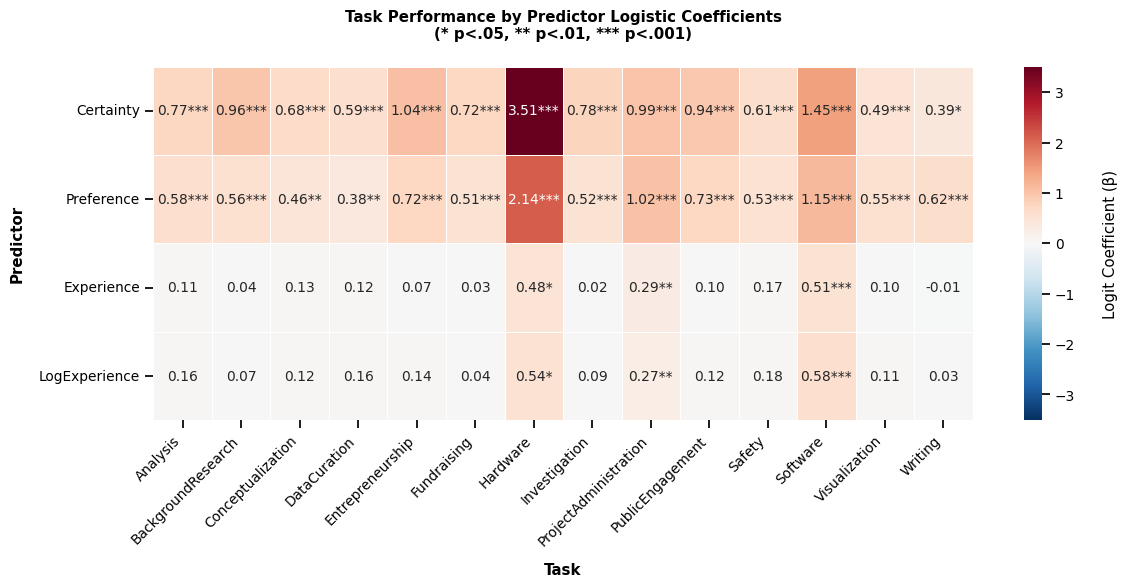

In [52]:
plot_task_heatmap_from_df(result_df)